# The emergence of urban scaling in Ancient Southwest Asia
### Reproducibility notebook — main text and supplementary material

**Authors:** Francesca Chelazzi (University of Glasgow, UK; University of Pisa, Italy) and Dan Lawrence (Durham University, UK)

**Manuscript:** Chelazzi, F. and Lawrence, D. (2026). *The emergence of urban scaling in Ancient Southwest Asia.* PLOS ONE.

**Repository DOI:** [10.5281/zenodo.20172244](https://doi.org/10.5281/zenodo.20172244)

---

### About this notebook

This is the **executable version** of the analysis. It reproduces all the tables and figures of the main text and the Supplementary Material, cell by cell, running directly in the browser. The same repository on Zenodo also contains the original R scripts (`main_text.R` and `supplementary_material.R`), which produce identical results when run in a standard R session; this notebook simply wraps both analysis scripts in an interactive, self-documenting form.

The dataset (`dataset.csv`) must be in the same folder as this notebook.

---

### Abstract

This study investigates the long-term emergence of settlement scaling in Ancient Southwest Asia by analysing house-size data from 1,852 buildings across 80 archaeological sites dating from the Late Epipalaeolithic to the Iron Age (c. 13,100–580 BCE). Using domestic architecture as a proxy for household productivity, we provide the first fully diachronic test of settlement scaling theory in the region where urbanisation first developed. Mixed-effects models reveal that scaling relationships were absent in the Neolithic, ambiguous in the Chalcolithic, and only fully emerged in the Bronze Age, where sub-linear exponents align with theoretical predictions for intensive socioeconomic outputs. These patterns persist into the Iron Age, indicating that strongly mixing interaction networks—central to settlement scaling theory—became structurally embedded only with the rise of urban complexity. Across periods, baseline house size more than doubles, suggesting long-term technological or organisational improvements independent of agglomeration effects. We also examine how scaling relates to economic inequality using Gini coefficients of residential size distributions. Inequality correlates with settlement size only in politically complex systems and primarily at major centres, indicating that institutional structures—not agglomeration-driven productivity—govern the allocation of returns. Residuals from scaling models do not predict inequality, demonstrating that productivity gains and their distribution operate through independent channels. Finally, we derive period-specific estimates of population density from the intercepts of area-population scaling relationships. These results document a marked decline in residential density from the Chalcolithic to the Bronze Age, followed by partial recovery in the Iron Age, aligning with independent reconstructions from sites such as Tell Brak. Overall, the study shows that scaling behaviours emerged only with sustained urban integration, and that inequality in early cities was shaped more by political institutions than by the geometric constraints of urban interaction.

---

*Licence: dataset CC-BY 4.0; code MIT. Free for academic and non-commercial use with attribution.*

## Setup

### Libraries, palette, categories and helper function

Load the R packages used throughout the analysis, define the colour palette (Okabe-Ito, colourblind-friendly) applied in all figures, set up the categorical variables that structure the analysis (the three polity groups and the two hierarchy positions), and define two small helper functions used to display result tables and figure captions cleanly throughout the notebook.

In [ ]:
# libraries
suppressPackageStartupMessages({
  library(tidyverse)
  library(lme4)
  library(lmerTest)
  library(MuMIn)
  library(DescTools)
  library(patchwork)
  library(ggplot2)
  library(influence.ME)
})

# colour palette (Okabe-Ito, colourblind-friendly)
okabe_ito <- c("#E69F00", "#56B4E9", "#009E73", "#F0E442",
               "#0072B2", "#D55E00", "#CC79A7", "#000000")
period_cols <- setNames(okabe_ito[c(1, 2, 3, 5)],
                        c("Neolithic", "Chalcolithic", "Bronze Age", "Iron Age"))
polity_cols <- setNames(okabe_ito[c(2, 3, 6)],
                        c("Low (Family/Local)", "Mid (Big Man/Chiefdoms)", "High (States/Empires)"))
rank_cols   <- setNames(okabe_ito[c(5, 1)],
                        c("Major centre", "Minor/peripheral"))

# helper: display tables as clean HTML
show_table <- function(df, caption = NULL) {
  ncol_df <- ncol(df)
  caption_html <- if (!is.null(caption)) {
    paste0("<div style='font-weight:bold;margin-bottom:6px;'>", caption, "</div>")
  } else ""
  suppressWarnings(IRdisplay::display_html(
    paste0(
      caption_html,
      "<table style='border-collapse:collapse;font-size:13px;'>",
      "<tr>",
      paste0(
        "<th style='border:1px solid #ccc;padding:4px 10px;font-weight:bold;",
        ifelse(seq_len(ncol_df) == 1, "text-align:left;", "text-align:center;"),
        "'>", names(df), "</th>",
        collapse = ""
      ),
      "</tr>",
      paste0(apply(df, 1, function(r)
        paste0(
          "<tr>",
          paste0(
            "<td style='border:1px solid #ccc;padding:4px 10px;",
            ifelse(seq_along(r) == 1, "text-align:left;", "text-align:center;"),
            "'>", r, "</td>",
            collapse = ""
          ),
          "</tr>"
        )), collapse = ""),
      "</table>"
    )
  ))
}

# helper: figure/section caption in bold
fig_caption <- function(text) {
  suppressWarnings(IRdisplay::display_html(
    paste0("<div style='font-weight:bold;margin-bottom:6px;'>", text, "</div>")
  ))
}

# confirmation
cat("All packages have been loaded successfully.\n")

Warning message:
"il pacchetto 'tidyverse' è stato creato con R versione 4.4.1"
Warning message:
"il pacchetto 'ggplot2' è stato creato con R versione 4.4.3"
Warning message:
"il pacchetto 'readr' è stato creato con R versione 4.4.1"
Warning message:
"il pacchetto 'forcats' è stato creato con R versione 4.4.2"
Warning message:
"il pacchetto 'lubridate' è stato creato con R versione 4.4.3"
Warning message:
"il pacchetto 'lme4' è stato creato con R versione 4.4.1"
Warning message:
"il pacchetto 'lmerTest' è stato creato con R versione 4.4.1"
Warning message:
"il pacchetto 'MuMIn' è stato creato con R versione 4.4.1"
Warning message:
"il pacchetto 'DescTools' è stato creato con R versione 4.4.1"
Warning message:
"il pacchetto 'patchwork' è stato creato con R versione 4.4.2"
Warning message:
"il pacchetto 'influence.ME' è stato creato con R versione 4.4.3"


All packages have been loaded successfully.


### Loading and filtering the dataset

Load the dataset (`dataset.csv`), which contains the full Southwest Asian contribution to the GINI Project database (see the paper for details). Apply the validity filtering used throughout the study: a record enters the analysis only if it has both a settlement area (`TotalArea`) and a house area (`TotalAreaHouse`) that are present and greater than zero. On the filtered sample, compute the log-transformed variables, flag palaces, assign each site to a polity group and a hierarchy position, and define the chronological ordering of periods used in the figures and tables.

In [7]:
# read the dataset (comma-separated, Latin-1 encoded)
scaling_dataset <- read_csv("dataset.csv",
                            locale = locale(encoding = "Latin1"),
                            show_col_types = FALSE)

# keep only records with valid settlement area and house area
data_clean <- scaling_dataset %>%
  filter(
    !is.na(TotalArea) & TotalArea > 0,
    !is.na(TotalAreaHouse) & TotalAreaHouse > 0
  ) %>%
  mutate(
    # log-transform the two size variables
    log_site_area  = log10(TotalArea),
    log_house_area = log10(TotalAreaHouse),
    # flag palatial buildings
    is_palace      = Housetypedesc == "Palace",
    # collapse the seven polity types into three complexity groups
    Polity_Group = case_when(
      TypeOfPolity %in% c(1, 2) ~ "Low (Family/Local)",
      TypeOfPolity %in% c(3, 4, 5) ~ "Mid (Big Man/Chiefdoms)",
      TypeOfPolity %in% c(6, 7) ~ "High (States/Empires)",
      TRUE ~ NA_character_
    ),
    Polity_Group = factor(Polity_Group, levels = c(
      "Low (Family/Local)", "Mid (Big Man/Chiefdoms)", "High (States/Empires)"
    )),
    # hierarchy position and major/minor centre split
    HP        = WhichLevel / NOfLevels,
    Site_rank = ifelse(HP >= 0.7, "Major centre", "Minor/peripheral")
  )

# fixed ordering of periods and polity groups for tables and figures
chronological_order <- c("Paleolithic", "Neolithic", "Chalcolithic", "Bronze Age", "Iron Age")
group_order <- c("Low (Family/Local)", "Mid (Big Man/Chiefdoms)", "High (States/Empires)")

# quick check on the analytical sample
cat("Rows in data_clean:", nrow(data_clean),
    "| sites:", n_distinct(data_clean$Site),
    "| site-phases:", n_distinct(data_clean$site_id), "\n")

Rows in data_clean: 1852 | sites: 80 | site-phases: 107 


### The baseline scaling model

Define the core statistical tool of the study: a linear mixed-effects model regressing log₁₀(house area) on log₁₀(site area), with a random intercept for site-phase to account for the non-independence of buildings within the same site-phase. The helper function below fits this model to any subset of the data and returns the scaling exponent β, its uncertainty, the variance components (including the intraclass correlation, ICC), and the marginal and conditional R². It is reused throughout both the main-text and Supplementary analyses.

In [8]:
# fit the baseline mixed-effects model and return its key statistics
calc_mixed <- function(data, label) {
  # random intercept for site-phase (buildings nested within site-phases)
  model <- lmer(log_house_area ~ log_site_area + (1 | site_id), data = data)
  s  <- summary(model); fe <- coef(s)
  # variance components and marginal/conditional R2
  vc <- as.data.frame(VarCorr(model)); r2 <- suppressWarnings(MuMIn::r.squaredGLMM(model))
  # assemble sample sizes, exponent, intercept, R2 and ICC into one row
  tibble(
    Analysis = label, N_buildings = nrow(data),
    N_sites = data %>% distinct(Site) %>% nrow(),
    N_site_phases = data %>% distinct(site_id) %>% nrow(),
    Beta = fe["log_site_area", "Estimate"], SE = fe["log_site_area", "Std. Error"],
    df_satt = fe["log_site_area", "df"], P_value = fe["log_site_area", "Pr(>|t|)"],
    Intercept = fe["(Intercept)", "Estimate"], SE_int = fe["(Intercept)", "Std. Error"],
    R2_marginal = r2[1, "R2m"], R2_conditional = r2[1, "R2c"],
    ICC = vc$vcov[1] / sum(vc$vcov),
    Var_site = vc$vcov[1], Var_residual = vc$vcov[2]
  )
}

cat("The mixed-effects model function (calc_mixed) is ready.\n")

The mixed-effects model function (calc_mixed) is ready.


---

# Main text analyses

This part of the notebook reproduces the analyses reported in the main text, in the order in which they appear in the paper. It produces the following outputs:

- **Section 1 — Baseline scaling** → Table 2 (baseline mixed-effects model with within-site bootstrap)
- **Section 2 — Chronological scaling** → Figure 2
- **Section 3 — Range restriction test** → result cited in the Discussion (no table or figure)
- **Section 4 — Model comparison** (chronology vs geography vs additive) → Table 3
- **Section 5 — Inequality** → Gini by polity group and hierarchy → Table 4 and Figure 3
- **Section 6 — Density scaling and population estimates** → Tables 5-6 and Figure 4
- **Section 7 — Scaling residuals vs inequality** → Figure 5

Each section is preceded by a short description of what it does and what it produces.

## Section 1 — Baseline scaling

Fit the baseline mixed-effects model on the full dataset, first including and then excluding palatial buildings, to test whether palaces drive the scaling relationship (they do not, so all subsequent analyses retain them). Then quantify the uncertainty of the exponent with a within-site bootstrap: houses are resampled with replacement within each site-phase, holding the set of sites and each site's sample size fixed, and the model is refitted to 1000 resampled datasets. 

**Produces Table 2.**

In [9]:
# fit the baseline model with and without palaces
mixed_1a <- calc_mixed(data_clean, "With palaces")
mixed_1b <- calc_mixed(data_clean %>% filter(!is_palace), "Without palaces")

# test whether the two exponents differ
beta_diff <- mixed_1a$Beta - mixed_1b$Beta
se_diff   <- sqrt(mixed_1a$SE^2 + mixed_1b$SE^2)
t_stat    <- beta_diff / se_diff
df_min    <- min(mixed_1a$df_satt, mixed_1b$df_satt)
p_diff    <- 2 * pt(-abs(t_stat), df = df_min)

# within-site bootstrap of the exponent: resample houses within each site-phase
set.seed(42)
R_BOOT <- 1000
boot_within_site <- function(data, R = R_BOOT) {
  idx <- split(seq_len(nrow(data)), data$site_id)
  vapply(seq_len(R), function(r) {
    take <- unlist(lapply(idx, function(ix) sample(ix, length(ix), replace = TRUE)),
                   use.names = FALSE)
    tryCatch(
      lme4::fixef(
        lme4::lmer(log_house_area ~ log_site_area + (1 | site_id),
                   data = data[take, ], control = lmerControl(calc.derivs = FALSE))
      )[["log_site_area"]],
      error = function(e) NA_real_
    )
  }, numeric(1))
}
boot_a <- boot_within_site(data_clean)
boot_b <- boot_within_site(data_clean %>% filter(!is_palace))

# helper for the bootstrap 95% confidence interval
ci_str <- function(b) paste0("[", round(quantile(b, 0.025, na.rm = TRUE), 3), ", ",
                             round(quantile(b, 0.975, na.rm = TRUE), 3), "]")

# Table 2
table_02 <- tibble(
  Metric = c("Beta", "SE", "df_Satterthwaite", "R2_marginal", "R2_conditional",
             "ICC", "N_buildings", "N_sites", "N_site_phases", "p_value",
             "Beta_bootstrap_mean", "Beta_bootstrap_SE", "Beta_bootstrap_95CI"),
  With_palaces = c(
    round(mixed_1a$Beta, 4), round(mixed_1a$SE, 4), round(mixed_1a$df_satt, 1),
    round(mixed_1a$R2_marginal, 4), round(mixed_1a$R2_conditional, 4),
    round(mixed_1a$ICC, 4), mixed_1a$N_buildings, mixed_1a$N_sites,
    mixed_1a$N_site_phases, formatC(mixed_1a$P_value, format = "e", digits = 2),
    round(mean(boot_a, na.rm = TRUE), 4), round(sd(boot_a, na.rm = TRUE), 4), ci_str(boot_a)
  ),
  Without_palaces = c(
    round(mixed_1b$Beta, 4), round(mixed_1b$SE, 4), round(mixed_1b$df_satt, 1),
    round(mixed_1b$R2_marginal, 4), round(mixed_1b$R2_conditional, 4),
    round(mixed_1b$ICC, 4), mixed_1b$N_buildings, mixed_1b$N_sites,
    mixed_1b$N_site_phases, formatC(mixed_1b$P_value, format = "e", digits = 2),
    round(mean(boot_b, na.rm = TRUE), 4), round(sd(boot_b, na.rm = TRUE), 4), ci_str(boot_b)
  ),
  Difference = c(
    round(beta_diff, 4), "-", "-",
    round(mixed_1a$R2_marginal - mixed_1b$R2_marginal, 4),
    round(mixed_1a$R2_conditional - mixed_1b$R2_conditional, 4),
    round(mixed_1a$ICC - mixed_1b$ICC, 4),
    mixed_1a$N_buildings - mixed_1b$N_buildings, 0, 0,
    paste0("t=", round(t_stat, 3), " p=", round(p_diff, 4), " (n.s.)"),
    "-", "-", "-"
  )
)

show_table(as.data.frame(table_02), "Table 2. Baseline scaling (mixed-effects model)")

Metric,With_palaces,Without_palaces,Difference
Beta,0.2977,0.2855,0.0122
SE,0.0384,0.0381,-
df_Satterthwaite,102.6,103,-
R2_marginal,0.2785,0.2772,0.0013
R2_conditional,0.6609,0.6897,-0.0288
ICC,0.53,0.5707,-0.0407
N_buildings,1852,1841,11
N_sites,80,80,0
N_site_phases,107,107,0
p_value,7.06e-12,2.42e-11,t=0.226 p=0.8214 (n.s.)


## Section 2 — Chronological scaling

Fit the mixed-effects model separately for each period (Neolithic, Chalcolithic, Bronze Age, Iron Age; periods with at least ten site-phases), to test when scaling first emerges. Then assemble Figure 2, which shows the log–log scatter of house area against site area coloured by period (panel a) and the scaling exponents with 95% confidence intervals positioned at the mean midpoint date of each period (panel b). 

**Produces Figure 2.**

From,To,Delta_Beta,t,p,sig
Neolithic,Chalcolithic,0.0466,0.249,0.8059,n.s.
Chalcolithic,Bronze Age,0.1479,1.117,0.2769,n.s.
Bronze Age,Iron Age,-0.0036,-0.046,0.9638,n.s.


Figure 2. Chronological variation in scaling relationships between residence size and settlement size. (a) Log-log scatter of building vs site area by period; (b) scaling exponents (β) with 95% CI by period.

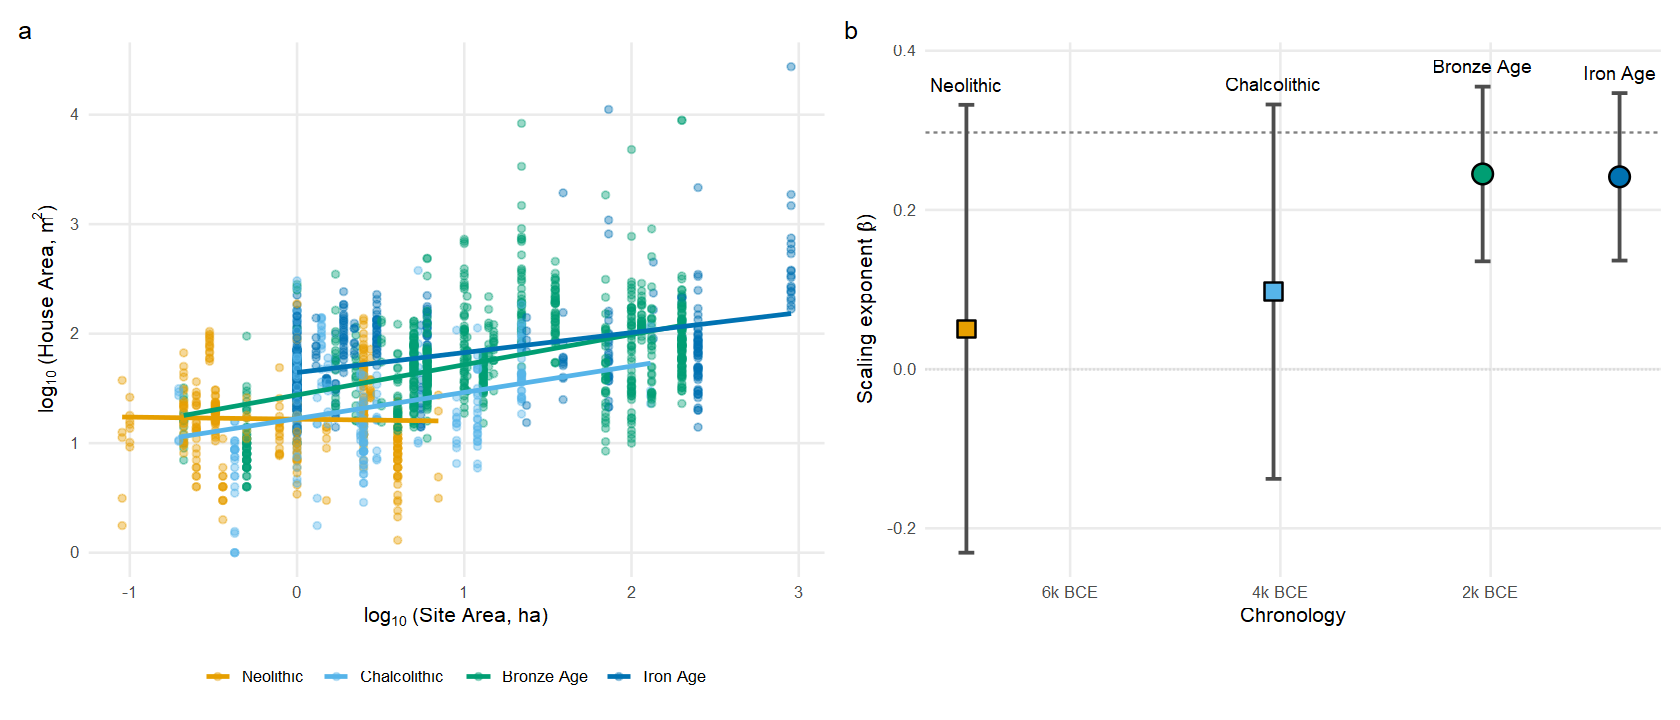

In [10]:
options(repr.plot.width = 14, repr.plot.height = 6)

# fit the model separately for each period with at least 10 site-phases
valid_periods <- data_clean %>%
  filter(SitePeriod != "Paleolithic") %>%
  group_by(SitePeriod) %>%
  summarise(N_site_phases = n_distinct(site_id), .groups = "drop") %>%
  filter(N_site_phases >= 10) %>%
  pull(SitePeriod)

level2_results <- list()
for (period in valid_periods) {
  period_data <- data_clean %>% filter(SitePeriod == period)
  result <- tryCatch(
    calc_mixed(period_data, period),
    error = function(e) {
      model <- lm(log_house_area ~ log_site_area, data = period_data)
      s <- summary(model)
      tibble(
        Analysis = period, N_buildings = nrow(period_data),
        N_sites = period_data %>% distinct(Site) %>% nrow(),
        N_site_phases = period_data %>% distinct(site_id) %>% nrow(),
        Beta = coef(model)[2], SE = s$coefficients[2, 2],
        df_satt = NA_real_, P_value = s$coefficients[2, 4],
        R2_marginal = s$r.squared, R2_conditional = NA_real_,
        ICC = NA_real_, Var_site = NA_real_, Var_residual = NA_real_
      )
    }
  )
  level2_results[[period]] <- result
}
level2_table <- bind_rows(level2_results) %>%
  mutate(Analysis = factor(Analysis, levels = chronological_order))

# pairwise comparison of exponents between consecutive periods
valid_ordered <- as.character(sort(factor(valid_periods, levels = chronological_order)))
pairwise_results <- list()
for (i in 1:(length(valid_ordered) - 1)) {
  p1 <- valid_ordered[i]; p2 <- valid_ordered[i + 1]
  r1 <- level2_results[[p1]]; r2 <- level2_results[[p2]]
  d_beta <- r2$Beta - r1$Beta
  d_se   <- sqrt(r1$SE^2 + r2$SE^2)
  d_t    <- d_beta / d_se
  d_df   <- min(r1$df_satt, r2$df_satt, na.rm = TRUE)
  d_p    <- 2 * pt(-abs(d_t), df = d_df)
  pairwise_results[[paste(p1, p2, sep = "_")]] <- tibble(
    From = p1, To = p2,
    Delta_Beta = round(d_beta, 4),
    t = round(d_t, 3),
    p = round(d_p, 4),
    sig = if (d_p < 0.001) "***" else if (d_p < 0.01) "**" else if (d_p < 0.05) "*" else "n.s."
  )
}
pairwise_table <- bind_rows(pairwise_results)

show_table(as.data.frame(pairwise_table), "Pairwise comparisons of scaling exponents between consecutive periods (cited in Results; none individually significant)")
cat("\n")

# mean midpoint date of each period, for the x axis of panel b
period_midpoints <- data_clean %>%
  filter(SitePeriod %in% as.character(level2_table$Analysis)) %>%
  mutate(midpoint = (as.numeric(BeginSite) + as.numeric(EndSite)) / 2) %>%
  group_by(SitePeriod) %>%
  summarise(date_mid = mean(midpoint, na.rm = TRUE), .groups = "drop")

# prepare exponents with confidence intervals for panel b
fig2_forest <- level2_table %>%
  mutate(
    Analysis = as.character(Analysis),
    CI_low   = Beta - 1.96 * SE,
    CI_high  = Beta + 1.96 * SE,
    Sig      = ifelse(P_value < 0.05, "Significant", "Not significant")
  ) %>%
  filter(!is.na(Analysis)) %>%
  left_join(period_midpoints, by = c("Analysis" = "SitePeriod"))

plot_data <- data_clean %>%
  filter(SitePeriod %in% as.character(level2_table$Analysis)) %>%
  mutate(SitePeriod = factor(SitePeriod, levels = chronological_order))

# prepare panel a: log-log scatter with a regression line per period
panel_a <- ggplot(plot_data, aes(x = log_site_area, y = log_house_area, colour = SitePeriod)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, linewidth = 1) +
  scale_colour_manual(values = period_cols) +
  labs(
    x = expression(log[10] ~ "(Site Area, ha)"),
    y = expression(log[10] ~ "(House Area, m"^2 * ")"),
    colour = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom", panel.grid.minor = element_blank())

# prepare panel b: exponents with 95% CI positioned at each period's midpoint date
panel_b <- ggplot(fig2_forest, aes(x = date_mid, y = Beta)) +
  geom_hline(yintercept = mixed_1a$Beta, linetype = "dashed", colour = "grey50", linewidth = 0.5) +
  geom_hline(yintercept = 0, linetype = "dotted", colour = "grey80") +
  geom_errorbar(aes(ymin = CI_low, ymax = CI_high), width = 150, linewidth = 0.8, colour = "grey30") +
  geom_point(aes(fill = Analysis, shape = Sig), size = 5, stroke = 0.8) +
  geom_text(aes(label = Analysis, y = CI_high + 0.025), size = 4, hjust = 0.5) +
  scale_fill_manual(values = period_cols) +
  scale_shape_manual(values = c("Significant" = 21, "Not significant" = 22)) +
  scale_x_continuous(
    breaks = seq(-10000, 0, by = 2000),
    labels = function(x) paste0(abs(x / 1000), "k BCE")
  ) +
  labs(x = "Chronology", y = expression("Scaling exponent (" * beta * ")")) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none", panel.grid.minor = element_blank())

# Figure 2 (combine the two panels side by side)
fig_2 <- (panel_a + labs(tag = "a")) | (panel_b + labs(tag = "b"))

fig_caption("Figure 2. Chronological variation in scaling relationships between residence size and settlement size. (a) Log-log scatter of building vs site area by period; (b) scaling exponents (β) with 95% CI by period.")
fig_2

## Section 3 — Range restriction test

Test whether the absence of scaling in the Neolithic is simply an artefact of its narrow range of settlement sizes. Restrict the Bronze Age sample to the same site-area range as the Neolithic, refit the mixed-effects model, and check whether scaling still emerges. 

**Produces a single result cited in the Discussion** (β ≈ 0.381), with no table or figure.

In [11]:
# restrict the Bronze Age sample to the Neolithic range of settlement sizes
neo           <- data_clean %>% filter(SitePeriod == "Neolithic")
neo_range     <- range(neo$log_site_area)
ba            <- data_clean %>% filter(SitePeriod == "Bronze Age")
ba_restricted <- ba %>% filter(log_site_area >= neo_range[1] & log_site_area <= neo_range[2])

# refit the model on the restricted range and check whether scaling still holds
m_restricted <- lmer(log_house_area ~ log_site_area + (1 | site_id), data = ba_restricted)
rr_result    <- coef(summary(m_restricted))["log_site_area", ]

cat("Range restriction test: β =", round(rr_result["Estimate"], 3),
    ", p =", round(rr_result["Pr(>|t|)"], 3),
    ", N site-phases =", n_distinct(ba_restricted$site_id), "\n")

Range restriction test: β = 0.381 , p = 0.001 , N site-phases = 19 


## Section 4 — Model comparison: chronology vs geography vs additive

Compare three mixed-effects models to disentangle whether scaling variation is structured by chronology, by geography, or by both independently: a chronology-only model (slopes varying by period), a geography-only model (slopes varying by region), and an additive model including both. Compare them with likelihood-ratio tests, AIC and BIC. 

**Produces Table 3.**

In [12]:
# prepare the data with period and region as factors
data_geo_chrono <- data_clean %>%
  filter(SitePeriod != "Paleolithic") %>%
  mutate(
    SitePeriod = factor(SitePeriod, levels = c("Neolithic", "Chalcolithic",
                                               "Bronze Age", "Iron Age")),
    Subarea    = factor(Subarea)
  )

# fit the three competing models: chronology only, geography only, and both
m_chrono   <- lmer(log_house_area ~ log_site_area * SitePeriod + (1 | site_id),
                   data = data_geo_chrono)
m_geo      <- lmer(log_house_area ~ log_site_area * Subarea + (1 | site_id),
                   data = data_geo_chrono)
m_additive <- lmer(log_house_area ~ log_site_area * SitePeriod +
                     log_site_area * Subarea + (1 | site_id),
                   data = data_geo_chrono)

# variance explained by each model
r2_chrono   <- suppressWarnings(MuMIn::r.squaredGLMM(m_chrono))
r2_geo      <- suppressWarnings(MuMIn::r.squaredGLMM(m_geo))
r2_additive <- suppressWarnings(MuMIn::r.squaredGLMM(m_additive))

# likelihood-ratio tests: does adding geography (or chronology) improve fit?
lrt_geo    <- suppressMessages(anova(m_chrono, m_additive))
lrt_chrono <- suppressMessages(anova(m_geo, m_additive))

# Table 3
table_03 <- tibble(
  Model = c("Chronology only", "Geography only", "Additive (both)",
            "Chrono vs Additive (LRT)", "Geo vs Additive (LRT)"),
  Fixed_effects = c(
    "site area × period", "site area × region",
    "site area × period + site area × region", "", ""
  ),
  AIC = c(round(AIC(m_chrono), 1), round(AIC(m_geo), 1),
          round(AIC(m_additive), 1), NA, NA),
  BIC = c(round(BIC(m_chrono), 1), round(BIC(m_geo), 1),
          round(BIC(m_additive), 1), NA, NA),
  R2_marginal = c(
    round(r2_chrono[1, "R2m"], 4), round(r2_geo[1, "R2m"], 4),
    round(r2_additive[1, "R2m"], 4), NA, NA
  ),
  R2_conditional = c(
    round(r2_chrono[1, "R2c"], 4), round(r2_geo[1, "R2c"], 4),
    round(r2_additive[1, "R2c"], 4), NA, NA
  ),
  Chi_sq = c(NA, NA, NA, round(lrt_geo$Chisq[2], 1), round(lrt_chrono$Chisq[2], 1)),
  LRT_df = c(NA, NA, NA, lrt_geo$Df[2], lrt_chrono$Df[2]),
  LRT_p  = c(NA, NA, NA,
             formatC(lrt_geo$`Pr(>Chisq)`[2], format = "e", digits = 2),
             formatC(lrt_chrono$`Pr(>Chisq)`[2], format = "e", digits = 2))
)

show_table(as.data.frame(table_03), "Table 3. Comparison of chronology-only, geography-only, and additive mixed-effects models")

Model,Fixed_effects,AIC,BIC,R2_marginal,R2_conditional,Chi_sq,LRT_df,LRT_p
Chronology only,site area × period,1075.2,1130.3,0.3440,0.6486,NA,NA,NA
Geography only,site area × region,1075.9,1142.1,0.3609,0.6458,NA,NA,NA
Additive (both),site area × period + site area × region,1084.1,1183.4,0.4137,0.6521,NA,NA,NA
Chrono vs Additive (LRT),,NA,NA,NA,NA,32.0,8,9.19e-05
Geo vs Additive (LRT),,NA,NA,NA,NA,22.7,6,9.09e-04


## Section 5 — Inequality: Gini coefficient by polity group and hierarchy position

Compute the Gini coefficient of house sizes within each site-phase (site-phases with at least five measured buildings), then examine how within-site inequality relates to settlement size, broken down by polity group (low / mid / high complexity) and by hierarchy position (major centres, HP ≥ 0.7, vs minor/peripheral sites). 

**Produces Table 4 and Figure 3.**

Polity_group,Site_rank,N,Gini_mean,r,p,sig
Low (Family/Local),Major centre,32,0.275,-0.052,7.77e-01,n.s.
Mid (Big Man/Chiefdoms),Major centre,17,0.357,0.280,2.77e-01,n.s.
Mid (Big Man/Chiefdoms),Minor/peripheral,12,0.360,-0.144,6.56e-01,n.s.
High (States/Empires),Major centre,21,0.526,0.439,4.67e-02,*
High (States/Empires),Minor/peripheral,15,0.303,-0.087,7.58e-01,n.s.


Polity_group,N_site_phases,N_sites,Gini_mean,Gini_SD,r,p
Low (Family/Local),36,28,0.279,0.117,-0.019,9.14e-01
Mid (Big Man/Chiefdoms),29,22,0.358,0.135,0.088,6.49e-01
High (States/Empires),36,28,0.433,0.235,0.570,2.84e-04


Figure 3. Gini coefficient of house sizes vs settlement area (log10), faceted by polity group. Points coloured by hierarchy position (major centres HP>=0.7 vs minor/peripheral); dashed line marks 10 ha.

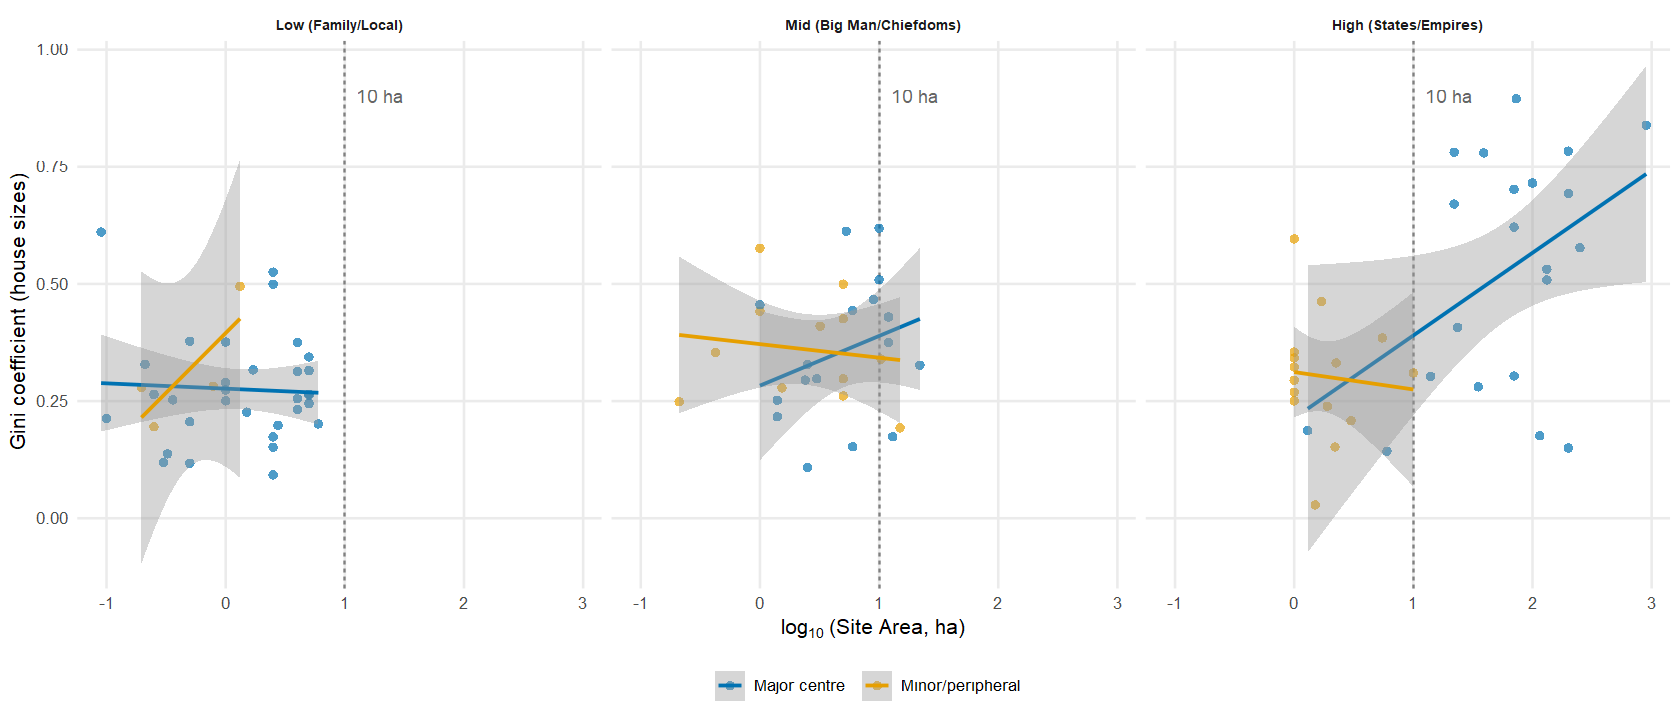

In [13]:
options(repr.plot.width = 14, repr.plot.height = 6)

# compute the Gini coefficient of house sizes for each site-phase and attach hierarchy position
gini_data <- data_clean %>%
  group_by(site_id, Site, TotalArea, log_site_area, Polity_Group,
           SitePeriod, Subarea) %>%
  summarise(
    N_houses   = n(),
    Gini = DescTools::Gini(TotalAreaHouse, unbiased = TRUE,
                           conf.level = 0.80, R = 1000, type = "perc")[1],
    Gini_lwr = DescTools::Gini(TotalAreaHouse, unbiased = TRUE,
                               conf.level = 0.80, R = 1000, type = "perc")[2],
    Gini_upr = DescTools::Gini(TotalAreaHouse, unbiased = TRUE,
                               conf.level = 0.80, R = 1000, type = "perc")[3],
    Mean_house = mean(TotalAreaHouse),
    .groups = "drop"
  ) %>%
  filter(N_houses >= 5) %>%
  left_join(
    data_clean %>%
      group_by(site_id) %>%
      summarise(
        HP        = first(na.omit(WhichLevel / NOfLevels)),
        Site_rank = ifelse(first(na.omit(WhichLevel / NOfLevels)) >= 0.7,
                           "Major centre", "Minor/peripheral"),
        .groups = "drop"
      ),
    by = "site_id"
  ) %>%
  mutate(Size_class = factor(ifelse(TotalArea >= 10, ">=10ha", "<10ha"),
                             levels = c("<10ha", ">=10ha")))

# correlate inequality with settlement size (split by polity group and hierarchy)
table_04 <- map_dfr(group_order, function(grp) {
  map_dfr(c("Major centre", "Minor/peripheral"), function(sr) {
    sub <- gini_data %>% filter(Polity_Group == grp, Site_rank == sr)
    if (nrow(sub) >= 5) {
      ct <- cor.test(sub$log_site_area, sub$Gini)
      tibble(
        Polity_group = grp, Site_rank = sr, N = nrow(sub),
        Gini_mean = round(mean(sub$Gini), 3),
        r = round(ct$estimate, 3),
        p = formatC(ct$p.value, format = "e", digits = 2),
        sig = if (ct$p.value < 0.001) "***" else if (ct$p.value < 0.01) "**" else
          if (ct$p.value < 0.05) "*" else "n.s."
      )
    }
  })
})

# same correlation aggregated to the three polity groups
table_04_aggregate <- map_dfr(group_order, function(grp) {
  sub <- gini_data %>% filter(Polity_Group == grp)
  if (nrow(sub) >= 5) {
    ct <- cor.test(sub$log_site_area, sub$Gini)
    tibble(
      Polity_group = grp,
      N_site_phases = nrow(sub),
      N_sites = n_distinct(sub$Site),
      Gini_mean = round(mean(sub$Gini), 3),
      Gini_SD = round(sd(sub$Gini), 3),
      r = round(as.numeric(ct$estimate), 3),
      p = formatC(ct$p.value, format = "e", digits = 2)
    )
  }
})

show_table(as.data.frame(table_04), "Table 4. Within-site inequality (Gini coefficient of house sizes) by polity group and hierarchy position")
cat("\n")
show_table(as.data.frame(table_04_aggregate), "Summary by polity group (values cited in the Results text)")
cat("\n")

# Figure 3
fig_3 <- ggplot(gini_data %>% filter(!is.na(Polity_Group), !is.na(Site_rank)),
                aes(x = log_site_area, y = Gini, colour = Site_rank,
                    shape = Site_rank)) +
  geom_vline(xintercept = log10(10), linetype = "dashed",
             colour = "grey50", linewidth = 0.5) +
  geom_point(alpha = 0.7, size = 2) +
  geom_smooth(method = "lm", se = TRUE, formula = y ~ x, linewidth = 0.8) +
  scale_colour_manual(values = rank_cols) +
  scale_shape_manual(values = c("Major centre" = 16, "Minor/peripheral" = 16)) +
  annotate("text", x = log10(10) + 0.1, y = 0.9, label = "10 ha",
           colour = "grey40", size = 4, hjust = 0) +
  facet_wrap(~ factor(Polity_Group, levels = group_order), ncol = 3) +
  labs(
    x = expression(log[10] ~ "(Site Area, ha)"),
    y = "Gini coefficient (house sizes)",
    colour = NULL, shape = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom", panel.grid.minor = element_blank(),
        strip.text = element_text(face = "bold", size = 8))

fig_caption(paste0(
  "Figure 3. Gini coefficient of house sizes vs settlement area (log10), faceted by polity group. ",
  "Points coloured by hierarchy position (major centres HP>=0.7 vs minor/peripheral); dashed line marks 10 ha."
))
fig_3

## Section 6 — Density scaling and population estimates

Estimate settlement population from household density. Aggregate to site-phase level, compute total households from the sampled window density, and apply a residential-proportion correction (larger sites devote proportionally less area to housing). Fit area–household scaling per period, both uncorrected and residential-corrected, and convert intercepts into population densities using a constant of five persons per household. Finally, derive population estimates at representative settlement sizes (1, 10, 100 ha). 

**Produces Table 5, Table 6 and Figure 4.**

Period,N_site_phases,Beta_uncorr,SE_uncorr,P_uncorr,Intercept_uncorr,HH_per_ha_uncorr,Pop_per_ha_uncorr,Beta_res,SE_res,P_res,Intercept_res,HH_per_ha_res,Pop_per_ha_res
Neolithic,24,0.517,0.171,6.28e-03,1.809,64.4,322,0.517,0.171,6.28e-03,1.809,64.4,322
Chalcolithic,18,0.950,0.197,1.88e-04,1.857,71.9,360,0.880,0.196,3.67e-04,1.802,63.4,317
Bronze Age,38,0.866,0.114,5.07e-09,1.605,40.3,201,0.789,0.113,3.29e-08,1.553,35.7,179
Iron Age,16,0.775,0.198,1.57e-03,1.666,46.4,232,0.694,0.198,3.47e-03,1.621,41.8,209


Period,Site_ha,HH_total,Pop_total,Pop_per_ha_at_size
Neolithic,1,64,320,320
Neolithic,10,212,1060,106
Neolithic,100,697,3485,35
Chalcolithic,1,63,315,315
Chalcolithic,10,481,2405,240
Chalcolithic,100,3648,18240,182
Bronze Age,1,36,180,180
Bronze Age,10,220,1100,110
Bronze Age,100,1352,6760,68
Iron Age,1,42,210,210


Figure 4. Area-household scaling per period: uncorrected (dashed) vs residential-corrected (solid). Grey points show uncorrected household counts; dotted line marks slope 2/3 for reference.

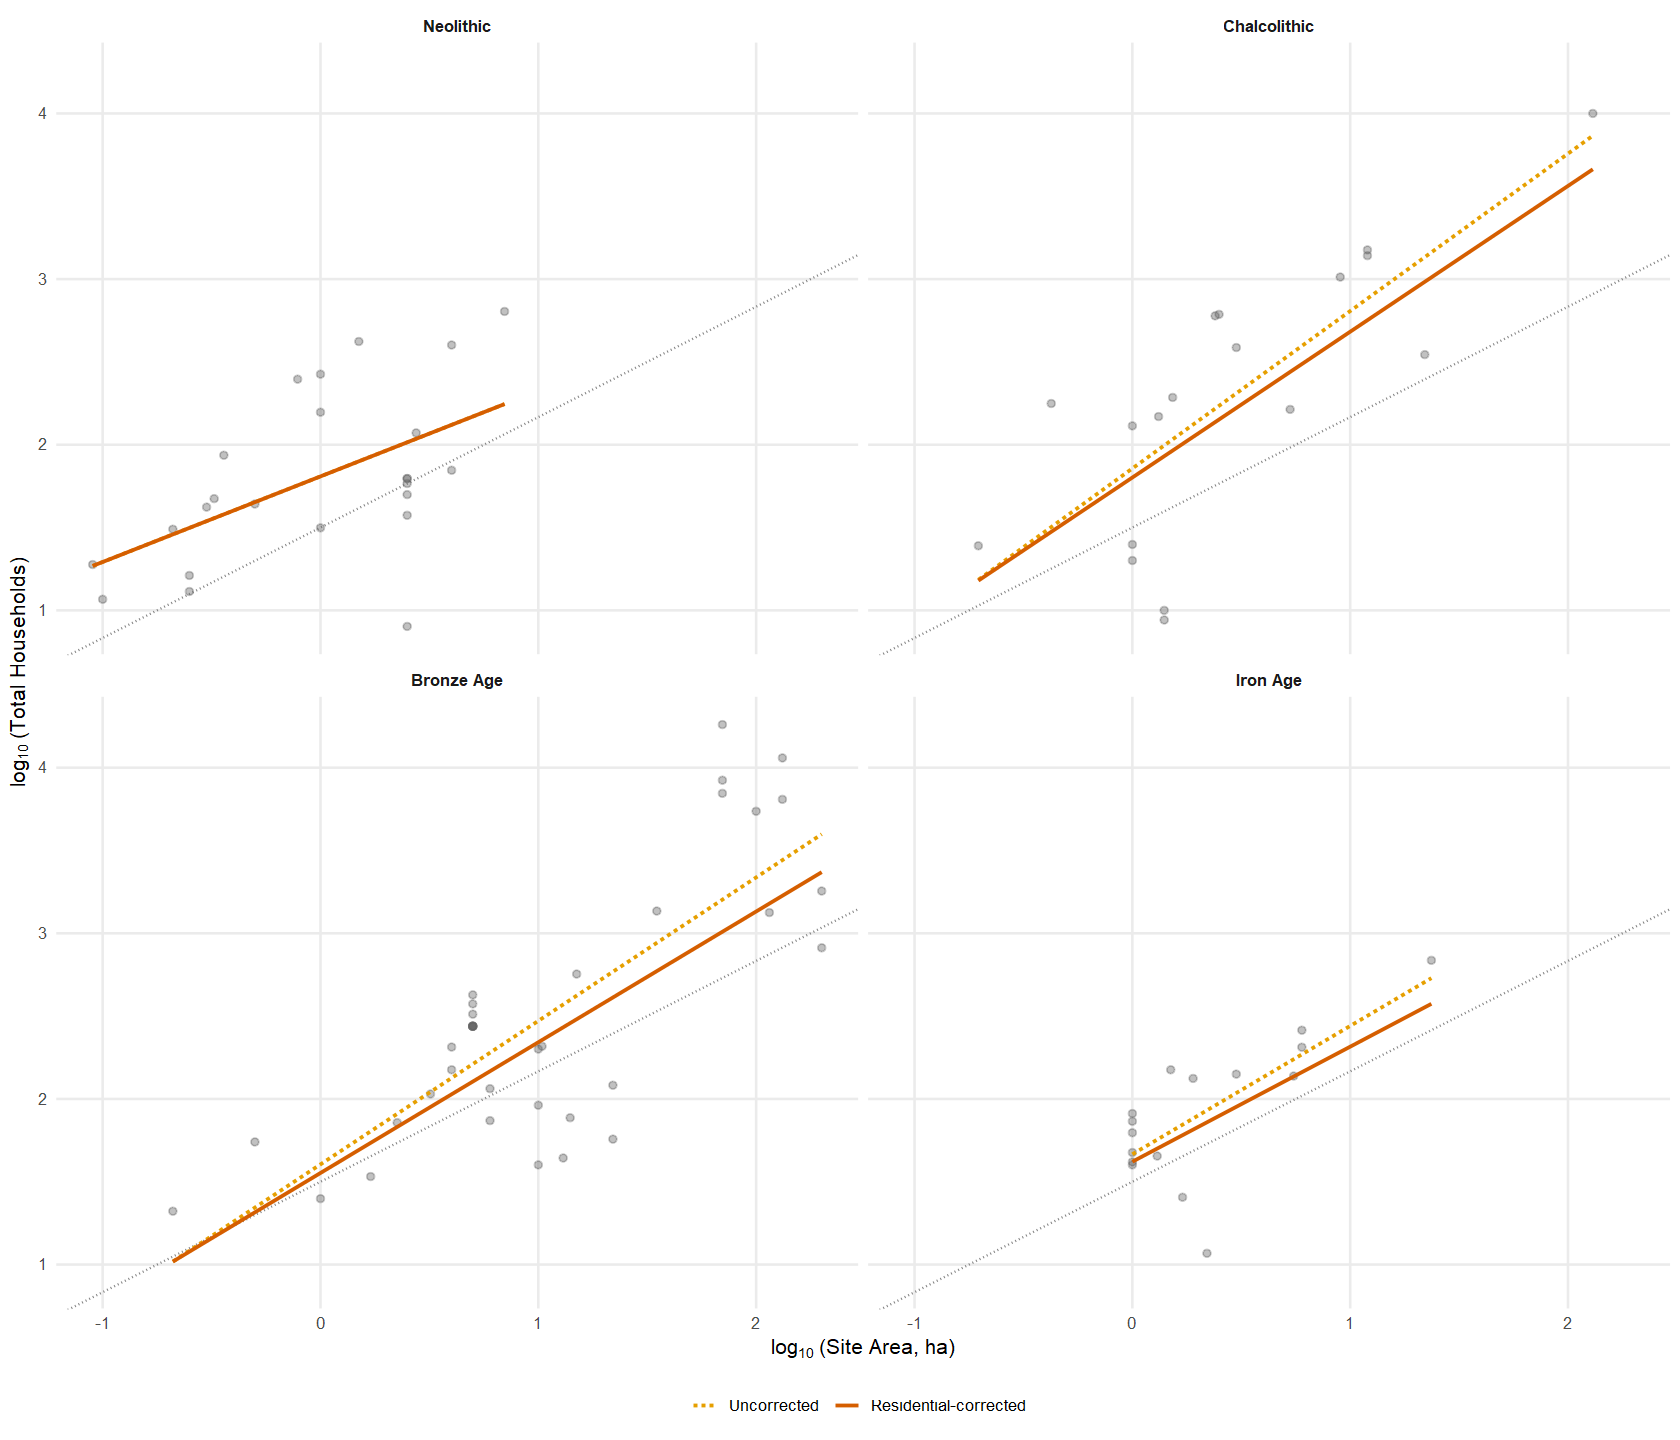

In [15]:
options(width = 200, repr.plot.width = 14, repr.plot.height = 12)

# clean and aggregate to site-phase level: drop two low-density outliers, then estimate total households from the sampled window density
KERKENES_ID <- 119113
ZINCIRLI_ID <- 119136

pop_data <- data_clean %>%
  filter(SitePeriod != "Paleolithic",
         !site_id %in% c(KERKENES_ID, ZINCIRLI_ID),
         !is.na(WindowArea), WindowArea > 0) %>%
  group_by(site_id, Site, SitePeriod, TotalArea, WindowArea) %>%
  summarise(
    WindowHH = n(),
    mean_HA  = mean(TotalAreaHouse, na.rm = TRUE),
    .groups  = "drop"
  ) %>%
  mutate(
    TotalHH       = (WindowHH / WindowArea) * TotalArea,
    log_TotalArea = log10(TotalArea),
    log_TotalHH   = log10(TotalHH),
    SitePeriod    = factor(SitePeriod, levels = c("Neolithic", "Chalcolithic",
                                                  "Bronze Age", "Iron Age"))
  )

# residential correction
pop_data <- pop_data %>%
  mutate(
    res_prop = case_when(
      SitePeriod == "Neolithic" ~ 1.0,
      TRUE ~ pmax(0.60, pmin(0.90, 0.90 - (0.30 * log10(TotalArea) / log10(100))))
    ),
    TotalHH_res     = TotalHH * res_prop,
    log_TotalHH_res = log10(TotalHH_res)
  )

# fit density scaling per period (uncorrected and corrected) and convert to densities
people_per_hh <- 5  # five persons per household (justified in the paper)
scaling_pop <- pop_data %>%
  group_by(SitePeriod) %>%
  group_map(~ {
    m_unc <- lm(log_TotalHH     ~ log_TotalArea, data = .x)
    m_res <- lm(log_TotalHH_res ~ log_TotalArea, data = .x)
    s_unc <- summary(m_unc); s_res <- summary(m_res)
    tibble(
      Period            = .y$SitePeriod,
      N_site_phases     = nrow(.x),
      Beta_uncorr       = round(coef(m_unc)[2], 3),
      SE_uncorr         = round(s_unc$coefficients[2, 2], 3),
      P_uncorr          = formatC(s_unc$coefficients[2, 4], format = "e", digits = 2),
      Intercept_uncorr  = round(coef(m_unc)[1], 3),
      HH_per_ha_uncorr  = round(10^coef(m_unc)[1], 1),
      Pop_per_ha_uncorr = round(10^coef(m_unc)[1] * people_per_hh, 0),
      Beta_res          = round(coef(m_res)[2], 3),
      SE_res            = round(s_res$coefficients[2, 2], 3),
      P_res             = formatC(s_res$coefficients[2, 4], format = "e", digits = 2),
      Intercept_res     = round(coef(m_res)[1], 3),
      HH_per_ha_res     = round(10^coef(m_res)[1], 1),
      Pop_per_ha_res    = round(10^coef(m_res)[1] * people_per_hh, 0)
    )
  }) %>% bind_rows()
table_05 <- scaling_pop

# population estimates at representative settlement sizes (1, 10, 100 ha)
site_sizes <- c(1, 10, 100)
table_06 <- expand_grid(
  Period   = factor(c("Neolithic", "Chalcolithic", "Bronze Age", "Iron Age"),
                    levels = c("Neolithic", "Chalcolithic",
                               "Bronze Age", "Iron Age")),
  Site_ha  = site_sizes
) %>%
  left_join(scaling_pop %>% select(Period, Intercept_res, Beta_res),
            by = "Period") %>%
  mutate(
    HH_total           = round(10^Intercept_res * Site_ha^Beta_res, 0),
    Pop_total          = round(HH_total * people_per_hh, 0),
    Pop_per_ha_at_size = round(Pop_total / Site_ha, 0)
  ) %>%
  select(Period, Site_ha, HH_total, Pop_total, Pop_per_ha_at_size)

show_table(as.data.frame(table_05), "Table 5. Density scaling per period (uncorrected and residential-corrected)")
show_table(as.data.frame(table_06), "Table 6. Estimated total population and density at representative settlement sizes, by period")
cat("\n")

# prepare data in long form for plotting both versions together
pop_data_long <- pop_data %>%
  select(site_id, SitePeriod, log_TotalArea,
         log_TotalHH, log_TotalHH_res) %>%
  pivot_longer(cols = starts_with("log_TotalHH"),
               names_to = "Version", values_to = "log_y") %>%
  mutate(Version = recode(Version,
                          "log_TotalHH"     = "Uncorrected",
                          "log_TotalHH_res" = "Residential-corrected"),
         Version = factor(Version, levels = c("Uncorrected",
                                              "Residential-corrected")))

# Figure 4
correction_cols <- setNames(okabe_ito[c(1, 6)],
                            c("Uncorrected", "Residential-corrected"))
fig_4 <- ggplot() +
  geom_abline(slope = 2/3, intercept = 1.5, linetype = "dotted",
              colour = "grey50", linewidth = 0.5) +
  geom_point(data = pop_data,
             aes(x = log_TotalArea, y = log_TotalHH),
             alpha = 0.4, size = 1.5, colour = "grey40") +
  geom_smooth(data = pop_data_long,
              aes(x = log_TotalArea, y = log_y,
                  colour = Version, linetype = Version),
              method = "lm", se = FALSE, formula = y ~ x, linewidth = 0.8) +
  scale_colour_manual(values = correction_cols) +
  scale_linetype_manual(values = c("Uncorrected"           = "dashed",
                                   "Residential-corrected" = "solid")) +
  facet_wrap(~ SitePeriod, ncol = 2) +
  labs(
    x        = expression(log[10] ~ "(Site Area, ha)"),
    y        = expression(log[10] ~ "(Total Households)"),
    colour   = NULL,
    linetype = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom",
        panel.grid.minor = element_blank(),
        strip.text = element_text(face = "bold")) +
  guides(colour = guide_legend(nrow = 1), linetype = guide_legend(nrow = 1))

fig_caption(paste0(
  "Figure 4. Area-household scaling per period: uncorrected (dashed) vs residential-corrected (solid). ",
  "Grey points show uncorrected household counts; dotted line marks slope 2/3 for reference."
))
fig_4

## Section 7 — Scaling residuals vs inequality

Test whether a settlement's deviation from the scaling relationship predicts its internal inequality. Extract the site-level random intercepts (BLUPs, denoted ξᵢ) from the baseline mixed-effects model — positive values mark site-phases whose houses are larger than predicted for their settlement size — and correlate them with the Gini coefficients computed in Section 5. 

**Produces Figure 5.**

Figure 5. Site-level scaling residuals (xi) vs Gini coefficients of house sizes (site-phases with >=5 buildings). Colours indicate polity group; filled circles = major centres (HP>=0.7), open circles = minor/peripheral. Dashed line = linear fit with 95% CI. r = -0.053, p = 0.597.

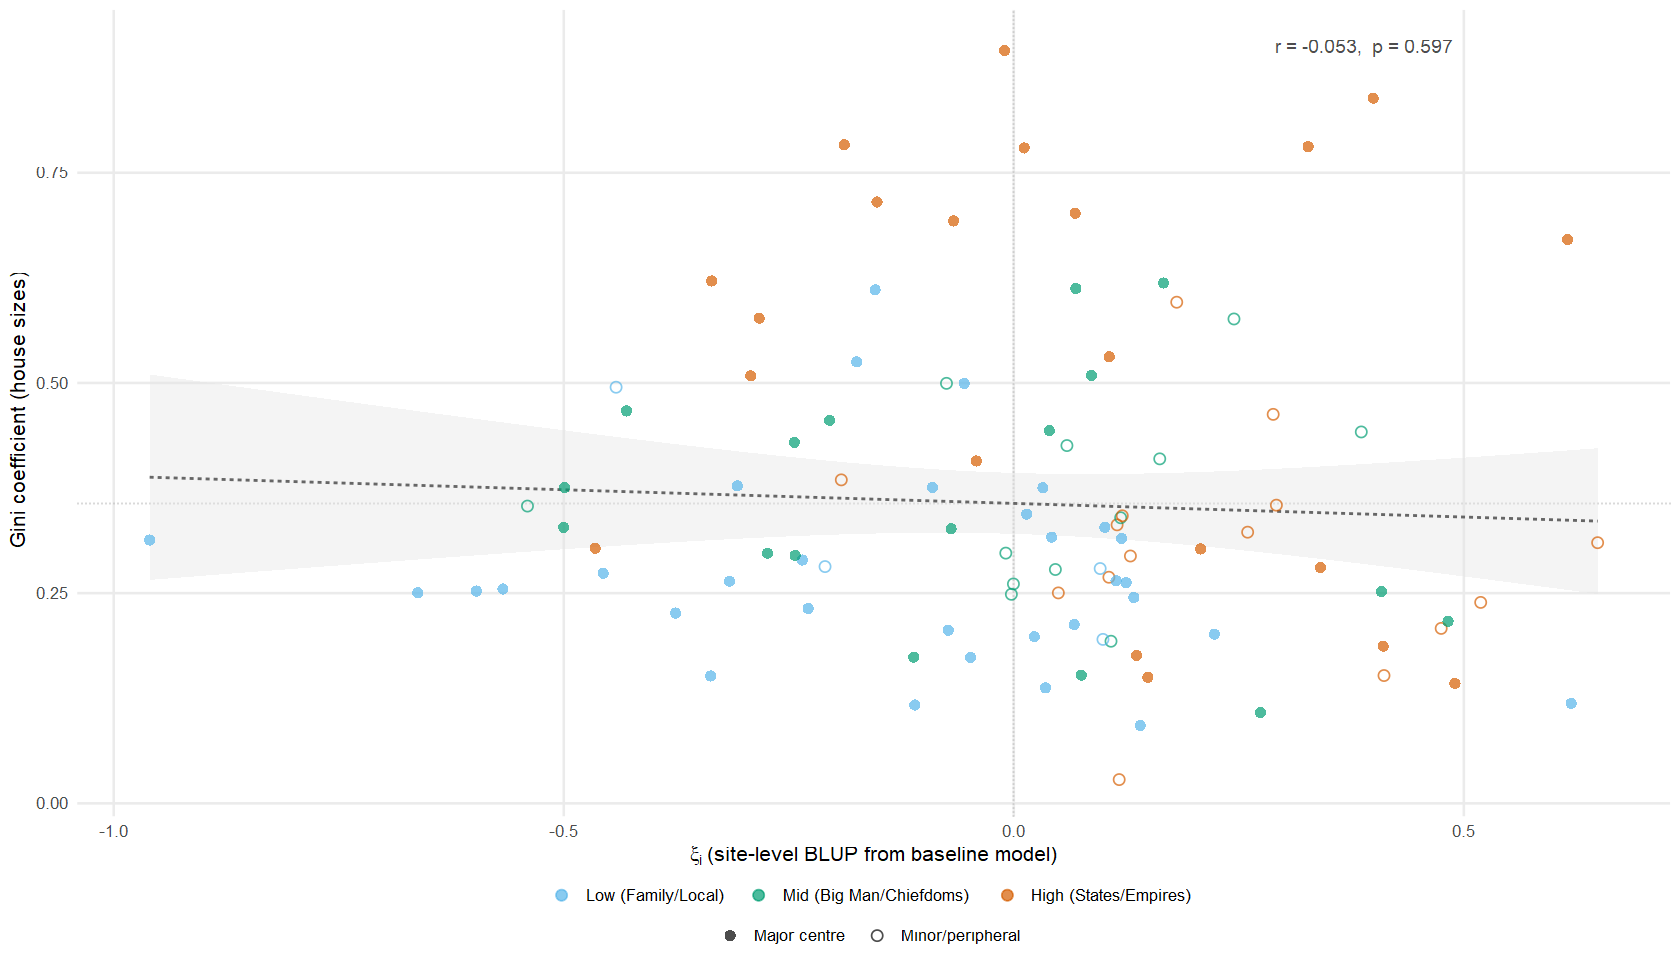

In [16]:
options(repr.plot.width = 14, repr.plot.height = 8)

# extract the site-level random intercepts from the baseline model
m_baseline <- lmer(log_house_area ~ log_site_area + (1 | site_id),
                   data = data_clean)
blups <- ranef(m_baseline)$site_id %>%
  rownames_to_column("site_id") %>%
  mutate(site_id = as.numeric(site_id)) %>%
  rename(xi = `(Intercept)`)

# join the residuals to the Gini data (from Section 5)
site_fig5 <- gini_data %>%
  select(site_id, Site, Gini, N_houses, Polity_Group, Site_rank,
         TotalArea, log_site_area, SitePeriod) %>%
  left_join(blups, by = "site_id") %>%
  filter(!is.na(xi), !is.na(Gini), !is.na(Polity_Group))

# correlate scaling residuals with inequality
ct_fig5   <- cor.test(site_fig5$xi, site_fig5$Gini)
ann_label <- paste0("r = ", round(ct_fig5$estimate, 3),
                    ",  p = ", round(ct_fig5$p.value, 3))

# Figure 5
fig_5 <- ggplot(site_fig5, aes(x = xi, y = Gini)) +
  geom_hline(yintercept = mean(site_fig5$Gini), linetype = "dotted",
             colour = "grey70", linewidth = 0.4) +
  geom_vline(xintercept = 0, linetype = "dotted", colour = "grey70",
             linewidth = 0.4) +
  geom_smooth(method = "lm", formula = y ~ x, se = TRUE, colour = "grey40",
              linetype = "dashed", linewidth = 0.6, fill = "grey90") +
  geom_point(aes(colour = Polity_Group, shape = Site_rank),
             size = 2.5, alpha = 0.7) +
  scale_colour_manual(values = polity_cols) +
  scale_shape_manual(values = c("Major centre" = 16, "Minor/peripheral" = 1)) +
  annotate("text", x = max(site_fig5$xi) * 0.6, y = 0.9,
           label = ann_label, size = 4, colour = "grey30") +
  labs(
    x = expression(xi[i] ~ "(site-level BLUP from baseline model)"),
    y = "Gini coefficient (house sizes)",
    colour = NULL, shape = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom", legend.box = "vertical",
        legend.margin = margin(t = -5), panel.grid.minor = element_blank()) +
  guides(colour = guide_legend(order = 1, nrow = 1),
         shape  = guide_legend(order = 2, nrow = 1))

fig_caption(paste0(
  "Figure 5. Site-level scaling residuals (xi) vs Gini coefficients of house sizes (site-phases with >=5 buildings). ",
  "Colours indicate polity group; filled circles = major centres (HP>=0.7), open circles = minor/peripheral. ",
  "Dashed line = linear fit with 95% CI. r = -0.053, p = 0.597."
))
fig_5

---

# Supplementary Material

This part of the notebook reproduces the analyses reported in the Supplementary Material, in the same order as in the document. It reuses the dataset, filtering, palette and helper functions defined in the Setup above. It produces the following outputs:

- **Section S1 — OLS vs mixed-effects comparison** → S1 Table
- **Section S2 — Sensitivity analysis** (individual buildings vs site-phase means/medians) → S2 Table
- **Section S3 — Robustness of the baseline exponent to individual sites** (leave-one-site-out) → S3 Table and S1 Fig
- **Section S4 — Chronological scaling** (with within-site bootstrap) → S4 Table and S2 Fig
- **Section S5 — Geographic scaling** → S5-S6 Tables
- **Section S6 — Regional robustness** (within-region and leave-one-region-out) → S7 Table and S8 Table
- **Section S7 — Scaling by political complexity** → S9 Table and S3 Fig
- **Section S8 — Robustness of the inequality results** (P90/P10 as alternative dispersion metric) → S10 Table and S4 Fig
- **Section S9 — Population density scaling and sensitivity** (residential correction) → S11-S12 Tables and S5 Fig
- **Section S10 — Tests on the Neolithic absence of scaling** → S13-S14 Tables and S6 Fig
- **Section S11 — Hierarchy Position threshold sensitivity** → S15 Table

Each section is preceded by a short description of what it does and what it produces.

## Section S1 — OLS vs mixed-effects comparison

The baseline analysis uses a mixed-effects model rather than ordinary least squares (OLS). This section justifies that choice: because buildings are nested within site-phases, OLS treats every building as independent and so understates the standard errors and overstates the effective sample size. Refit the baseline relationship with both OLS and the mixed model, with and without palaces, and compare the exponents, standard errors and effective degrees of freedom. The mixed model returns a similar exponent but a far smaller effective sample size, confirming that the random intercept is needed. 

**Produces S1 Table.**

In [17]:
options(width = 200)

# fit OLS and mixed-effects models, with and without palaces
ols_wp   <- lm(log_house_area ~ log_site_area, data = data_clean)
mixed_wp <- lmer(log_house_area ~ log_site_area + (1 | site_id), data = data_clean)
data_np  <- data_clean %>% filter(!is_palace)
ols_np   <- lm(log_house_area ~ log_site_area, data = data_np)
mixed_np <- lmer(log_house_area ~ log_site_area + (1 | site_id), data = data_np)

# extract summaries, variance explained, variance components and fixed effects
ols_wp_s   <- summary(ols_wp);   ols_np_s   <- summary(ols_np)
mixed_wp_s <- summary(mixed_wp); mixed_np_s <- summary(mixed_np)
r2_wp  <- suppressWarnings(MuMIn::r.squaredGLMM(mixed_wp))
r2_np  <- suppressWarnings(MuMIn::r.squaredGLMM(mixed_np))
vc_wp  <- as.data.frame(VarCorr(mixed_wp))
vc_np  <- as.data.frame(VarCorr(mixed_np))
fe_wp  <- coef(mixed_wp_s)
fe_np  <- coef(mixed_np_s)

# Table S1
table_s1 <- tibble(
  Metric = c("Beta", "SE", "R2", "p_value", "Effective_df",
             "R2_conditional", "ICC", "N_buildings", "N_site_phases"),
  OLS_with_palaces = c(
    round(coef(ols_wp)[2], 4), round(ols_wp_s$coefficients[2, 2], 4),
    round(ols_wp_s$r.squared, 4),
    formatC(ols_wp_s$coefficients[2, 4], format = "e", digits = 2),
    ols_wp$df.residual, NA, NA, nrow(data_clean), NA
  ),
  Mixed_with_palaces = c(
    round(fe_wp["log_site_area", "Estimate"], 4),
    round(fe_wp["log_site_area", "Std. Error"], 4),
    round(r2_wp[1, "R2m"], 4),
    formatC(fe_wp["log_site_area", "Pr(>|t|)"], format = "e", digits = 2),
    round(fe_wp["log_site_area", "df"], 1),
    round(r2_wp[1, "R2c"], 4),
    round(vc_wp$vcov[1] / sum(vc_wp$vcov), 4),
    nrow(data_clean), length(unique(data_clean$site_id))
  ),
  OLS_without_palaces = c(
    round(coef(ols_np)[2], 4), round(ols_np_s$coefficients[2, 2], 4),
    round(ols_np_s$r.squared, 4),
    formatC(ols_np_s$coefficients[2, 4], format = "e", digits = 2),
    ols_np$df.residual, NA, NA, nrow(data_np), NA
  ),
  Mixed_without_palaces = c(
    round(fe_np["log_site_area", "Estimate"], 4),
    round(fe_np["log_site_area", "Std. Error"], 4),
    round(r2_np[1, "R2m"], 4),
    formatC(fe_np["log_site_area", "Pr(>|t|)"], format = "e", digits = 2),
    round(fe_np["log_site_area", "df"], 1),
    round(r2_np[1, "R2c"], 4),
    round(vc_np$vcov[1] / sum(vc_np$vcov), 4),
    nrow(data_np), length(unique(data_np$site_id))
  )
)

show_table(as.data.frame(table_s1), "S1 Table. OLS vs mixed-effects model comparison (with and without palaces)")

Metric,OLS_with_palaces,Mixed_with_palaces,OLS_without_palaces,Mixed_without_palaces
Beta,0.2822,0.2977,0.2695,0.2855
SE,0.0108,0.0384,0.0104,0.0381
R2,0.2684,0.2785,0.2677,0.2772
p_value,1.02e-127,7.06e-12,1.44e-126,2.42e-11
Effective_df,1850,102.6,1839,103
R2_conditional,NA,0.6609,NA,0.6897
ICC,NA,0.53,NA,0.5707
N_buildings,1852,1852,1841,1841
N_site_phases,NA,107,NA,107


## Section S2 — Sensitivity to the unit of analysis

Check that the scaling result does not depend on treating individual buildings as the unit of analysis. Collapse each site-phase to a single value — first its mean, then its median log house area — and refit the relationship by OLS on these aggregated points. If the exponent is stable across the three approaches (individual buildings with the mixed model, site-phase means, site-phase medians), the baseline result is not an artefact of pooling many buildings from a few large sites. 

**Produces S2 Table.**

In [18]:
options(width = 200)

# collapse each site-phase to a single value: mean and median log house area
sitephase_means <- data_clean %>%
  group_by(site_id) %>%
  summarise(
    log_house_area = log10(mean(TotalAreaHouse)),
    log_site_area  = first(log_site_area), .groups = "drop"
  )

sitephase_medians <- data_clean %>%
  group_by(site_id) %>%
  summarise(
    log_house_area = log10(median(TotalAreaHouse)),
    log_site_area  = first(log_site_area), .groups = "drop"
  )

# fit OLS on the aggregated points
ols_means   <- lm(log_house_area ~ log_site_area, data = sitephase_means)
ols_medians <- lm(log_house_area ~ log_site_area, data = sitephase_medians)
ols_means_s   <- summary(ols_means)
ols_medians_s <- summary(ols_medians)

# compare the exponent across the three approaches (reuses the mixed-effects result from S1)
table_s2 <- tibble(
  Method = c("Individual houses (mixed-effects)",
             "Site-phase means (OLS)",
             "Site-phase medians (OLS)"),
  N = c(nrow(data_clean), nrow(sitephase_means), nrow(sitephase_medians)),
  Beta = c(
    round(fe_wp["log_site_area", "Estimate"], 4),
    round(coef(ols_means)[2], 4),
    round(coef(ols_medians)[2], 4)
  ),
  SE = c(
    round(fe_wp["log_site_area", "Std. Error"], 4),
    round(ols_means_s$coefficients[2, 2], 4),
    round(ols_medians_s$coefficients[2, 2], 4)
  ),
  R2 = c(
    round(r2_wp[1, "R2m"], 4),
    round(ols_means_s$r.squared, 4),
    round(ols_medians_s$r.squared, 4)
  ),
  p_value = c(
    formatC(fe_wp["log_site_area", "Pr(>|t|)"], format = "e", digits = 2),
    formatC(ols_means_s$coefficients[2, 4], format = "e", digits = 2),
    formatC(ols_medians_s$coefficients[2, 4], format = "e", digits = 2)
  )
)

show_table(as.data.frame(table_s2), "S2 Table. Sensitivity of the scaling exponent to the unit of analysis (individual buildings, site-phase means, site-phase medians)")

Method,N,Beta,SE,R2,p_value
Individual houses (mixed-effects),1852,0.2977,0.0384,0.2785,7.06e-12
Site-phase means (OLS),107,0.3807,0.0413,0.4478,3.30e-15
Site-phase medians (OLS),107,0.2634,0.0390,0.3024,8.52e-10


## Section S3 — Robustness of the baseline exponent to individual sites

Test whether the baseline exponent depends on any single site-phase. Using a formal leave-one-out procedure (the `influence.ME` package), refit the baseline model dropping each site-phase in turn, and record how much the exponent moves (Δβ), together with two standard influence diagnostics (DFBETAS and Cook's distance). If no single site-phase shifts the exponent beyond the conventional cutoffs, the baseline result is not driven by any individual site. 

**Produces S3 Table and S1 Fig.**

N_site_phases,Beta_full,Beta_LOO_min,Beta_LOO_max,Beta_LOO_SD,Max_abs_dBeta,DFBETAS_cutoff,CooksD_cutoff,N_influential
107,0.2977,0.2825,0.3085,0.0035,0.0152,0.193,0.0374,8


site_id,Beta_LOO,Delta_Beta,DFBETAS,Cooks_D,Site,SitePeriod
141104,0.2825423,-0.015193573,0.3809252,0.08081717,Babylon,Iron Age
119105,0.3084647,0.010728879,-0.2810624,0.05958746,Beidha,Neolithic
119114,0.2881565,-0.009579412,0.2509098,0.05045446,Khirokitia,Neolithic
141140,0.3065120,0.008776093,-0.2274407,0.03715811,Tell Chuera,Bronze Age
119137,0.3058874,0.008151533,-0.2096155,0.02838317,Tell Brak,Chalcolithic
141173,0.2896570,-0.008078851,0.2109556,0.03760678,Kuruçay Höyük,Chalcolithic
119113,0.3056664,0.007930512,-0.2012329,0.02429768,Kerkenes Da?,Iron Age
119153,0.3045600,0.006824119,-0.1745188,0.01958841,Tell Asmar,Bronze Age


S1 Fig. Change in the baseline scaling exponent (Δβ) when each site-phase is removed in turn (leave-one-out). No single site-phase shifts the exponent beyond the conventional influence cutoffs.

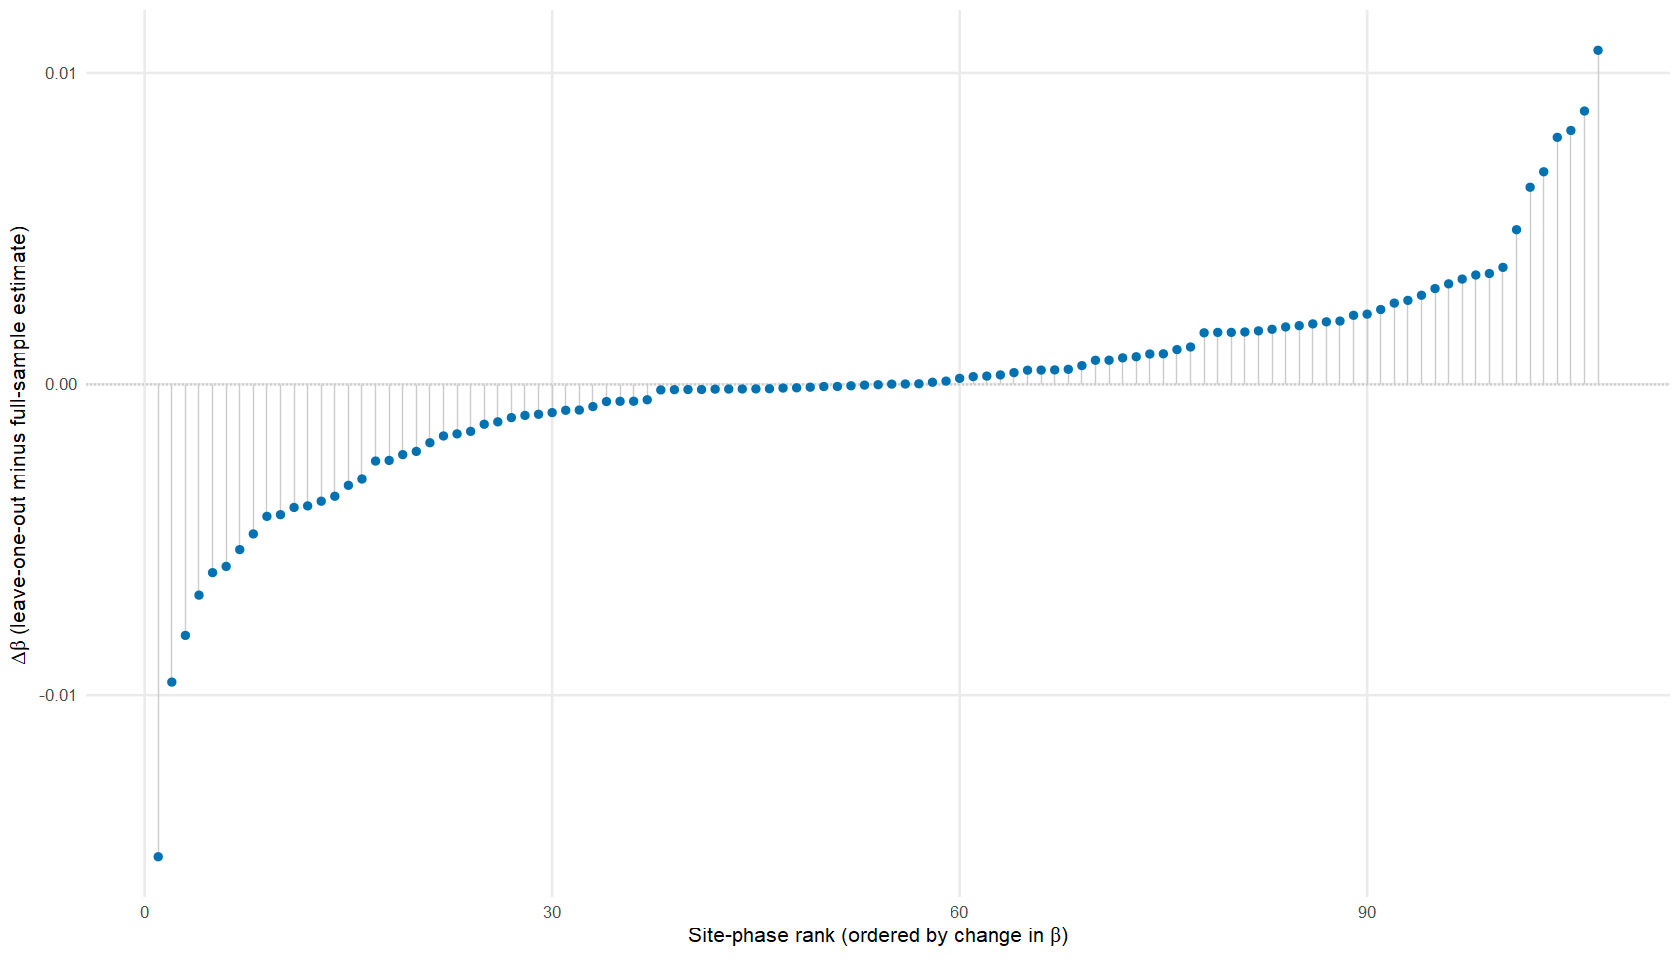

In [19]:
options(width = 200, repr.plot.width = 14, repr.plot.height = 8)

# refit the baseline model and record the full-sample exponent
m_base    <- lmer(log_house_area ~ log_site_area + (1 | site_id), data = data_clean)
beta_full <- fixef(m_base)[["log_site_area"]]

# Leave-one-out (+ formal diagnostics)
inf_sp  <- influence(m_base, group = "site_id")
loo_sp  <- inf_sp$alt.fixed[, "log_site_area"]
dfb_sp  <- dfbetas(inf_sp)[, "log_site_area"]
cook_sp <- cooks.distance(inf_sp)[, 1]

# how much each site-phase moves the exponent when removed
sp_diag <- tibble(
  site_id    = as.numeric(rownames(inf_sp$alt.fixed)),
  Beta_LOO   = as.numeric(loo_sp),
  Delta_Beta = as.numeric(loo_sp) - beta_full,
  DFBETAS    = as.numeric(dfb_sp),
  Cooks_D    = as.numeric(cook_sp)
) %>%
  left_join(distinct(data_clean, site_id, Site, SitePeriod), by = "site_id") %>%
  arrange(desc(abs(Delta_Beta)))

# Conventional cutoffs
dfb_cut  <- 2 / sqrt(nrow(inf_sp$alt.fixed))
cook_cut <- 4 / nrow(inf_sp$alt.fixed)

# Table S3
table_s3 <- tibble(
  N_site_phases = nrow(sp_diag),
  Beta_full     = round(beta_full, 4),
  Beta_LOO_min  = round(min(sp_diag$Beta_LOO), 4),
  Beta_LOO_max  = round(max(sp_diag$Beta_LOO), 4),
  Beta_LOO_SD   = round(sd(sp_diag$Beta_LOO), 4),
  Max_abs_dBeta = round(max(abs(sp_diag$Delta_Beta)), 4),
  DFBETAS_cutoff = round(dfb_cut, 3),
  CooksD_cutoff  = round(cook_cut, 4),
  N_influential = sum(abs(sp_diag$DFBETAS) > dfb_cut | sp_diag$Cooks_D > cook_cut)
)
show_table(as.data.frame(table_s3), "S3 Table. Leave-one-site-out robustness of the baseline exponent")

# Most influential site-phases (cited in the text)
show_table(as.data.frame(head(sp_diag, 8)), "Eight most influential site-phases (ordered by absolute change in beta)")

# Figure S1
cat_sp <- sp_diag %>% arrange(Delta_Beta) %>% mutate(rank = row_number())

fig_s1 <- ggplot(cat_sp, aes(x = rank, y = Delta_Beta)) +
  geom_hline(yintercept = 0, linetype = "dotted", colour = "grey70") +
  geom_segment(aes(xend = rank, yend = 0), colour = "grey80", linewidth = 0.3) +
  geom_point(size = 1.5, colour = okabe_ito[5]) +
  labs(
    x = expression("Site-phase rank (ordered by change in " * beta * ")"),
    y = expression(Delta * beta ~ "(leave-one-out minus full-sample estimate)")
  ) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

fig_caption(paste0(
  "S1 Fig. Change in the baseline scaling exponent (Δβ) when each site-phase is removed in turn ",
  "(leave-one-out). No single site-phase shifts the exponent beyond the conventional influence cutoffs."
))
fig_s1

## Section S4 — Chronological scaling with within-site bootstrap

Report the full chronological scaling results underlying Figure 2 of the main text, adding two elements. First, quantify the exponent for each period with a within-site bootstrap (as in the baseline). Second, examine the intercept Y0 — the predicted house size at a one-hectare settlement — across periods, testing for a temporal trend (linear fit) and for significant differences between consecutive periods (Wald z-tests). This documents both the emergence of scaling and the long-term growth in baseline house size. 

**Produces S4 Table and S2 Fig.**

Period,Beta,SE,df_Satt,P_value,R2_marginal,R2_conditional,ICC,Intercept,SE_int,Y0_m2,Y0_CI,N_buildings,N_sites,N_site_phases,Boot_mean,Boot_SE,Boot_CI
Bronze Age,0.2452,0.0560,35.2,1.02e-04,0.1991,0.4711,0.3396,1.5020,0.0711,31.8,"[23.1, 43.8]",808,26,38,0.2445,0.0164,"[0.213, 0.277]"
Chalcolithic,0.0973,0.1200,20.6,4.27e-01,0.0160,0.5112,0.5032,1.3610,0.0873,23.0,"[15.5, 34]",248,16,21,0.0964,0.0394,"[0.021, 0.177]"
Iron Age,0.2416,0.0537,20.3,2.12e-04,0.2935,0.5453,0.3565,1.6211,0.0664,41.8,"[31, 56.4]",452,18,22,0.2418,0.0183,"[0.205, 0.279]"
Neolithic,0.0507,0.1435,22.0,7.27e-01,0.0037,0.7421,0.7411,1.2275,0.0756,16.9,"[12, 23.8]",330,19,24,0.0507,0.0425,"[-0.036, 0.132]"


Y0 linear trend: R2 = 0.977 , p = 0.012 


From,To,Delta_Y0,z,p,sig
Neolithic,Chalcolithic,6.1,1.156,0.2478,n.s.
Chalcolithic,Bronze Age,8.8,1.253,0.2103,n.s.
Bronze Age,Iron Age,10.0,1.225,0.2206,n.s.


S2 Fig. Baseline house size Y0 (predicted house size at a 1 ha settlement) by period, with 95% CI. Dashed line shows the linear temporal trend.

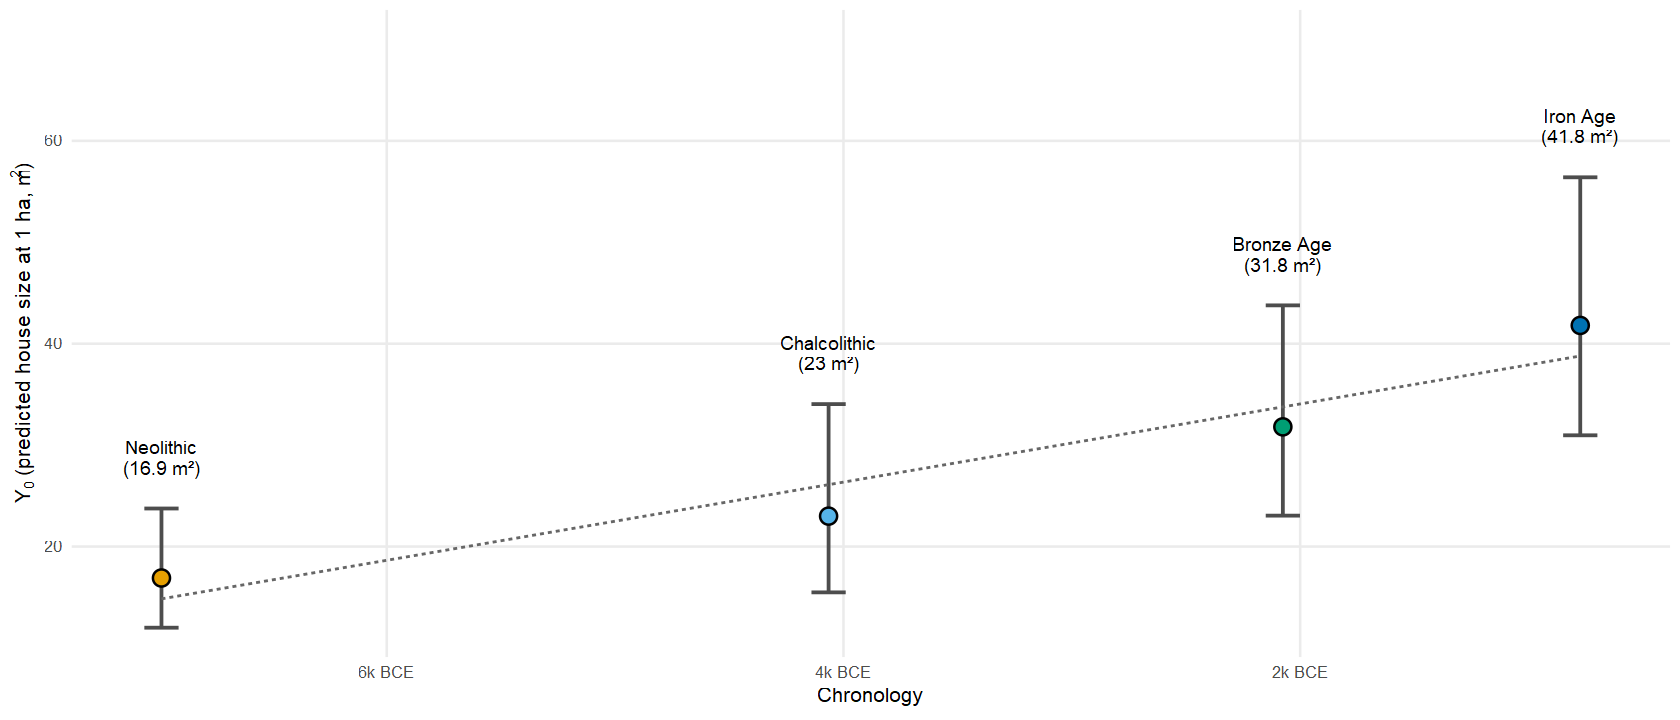

In [20]:
options(width = 200, repr.plot.width = 14, repr.plot.height = 6)

# fit the model per period (periods with at least 10 site-phases)
valid_periods <- data_clean %>%
  filter(SitePeriod != "Paleolithic") %>%
  group_by(SitePeriod) %>%
  summarise(N = n_distinct(site_id), .groups = "drop") %>%
  filter(N >= 10) %>%
  pull(SitePeriod)

chrono_results <- map(setNames(valid_periods, valid_periods), function(period) {
  calc_mixed(data_clean %>% filter(SitePeriod == period), period)
})

# within-site bootstrap per period
boot_by_period <- map_dfr(valid_periods, function(period) {
  b <- boot_within_site(data_clean %>% filter(SitePeriod == period))
  tibble(
    Period    = as.character(period),
    Boot_mean = round(mean(b, na.rm = TRUE), 4),
    Boot_SE   = round(sd(b, na.rm = TRUE), 4),
    Boot_CI   = paste0("[", round(quantile(b, 0.025, na.rm = TRUE), 3), ", ",
                       round(quantile(b, 0.975, na.rm = TRUE), 3), "]")
  )
})

# Table S4
chrono_table <- bind_rows(chrono_results) %>%
  mutate(
    Y0      = round(10^Intercept, 1),
    Y0_low  = round(10^(Intercept - 1.96 * SE_int), 1),
    Y0_high = round(10^(Intercept + 1.96 * SE_int), 1),
    Analysis = factor(Analysis, levels = chronological_order)
  )

table_s4 <- chrono_table %>%
  transmute(
    Period         = Analysis,
    Beta           = round(Beta, 4),
    SE             = round(SE, 4),
    df_Satt        = round(df_satt, 1),
    P_value        = formatC(P_value, format = "e", digits = 2),
    R2_marginal    = round(R2_marginal, 4),
    R2_conditional = round(R2_conditional, 4),
    ICC            = round(ICC, 4),
    Intercept      = round(Intercept, 4),
    SE_int         = round(SE_int, 4),
    Y0_m2          = Y0,
    Y0_CI          = paste0("[", Y0_low, ", ", Y0_high, "]"),
    N_buildings    = N_buildings,
    N_sites        = N_sites,
    N_site_phases  = N_site_phases
  ) %>%
  left_join(boot_by_period, by = c("Period" = "Period"))

show_table(as.data.frame(table_s4), "S4 Table. Chronological scaling per period, with within-site bootstrap and baseline house size Y0")

# period midpoints for temporal axis
period_midpoints <- data_clean %>%
  filter(SitePeriod %in% as.character(chrono_table$Analysis)) %>%
  mutate(midpoint = (as.numeric(BeginSite) + as.numeric(EndSite)) / 2) %>%
  group_by(SitePeriod) %>%
  summarise(date_mid = mean(midpoint, na.rm = TRUE), .groups = "drop")

fig_s2_data <- chrono_table %>%
  left_join(period_midpoints, by = c("Analysis" = "SitePeriod")) %>%
  mutate(
    Y0_low  = 10^(Intercept - 1.96 * SE_int),
    Y0_high = 10^(Intercept + 1.96 * SE_int)
  )

# linear trend in Y0
lm_y0   <- lm(Intercept ~ date_mid, data = fig_s2_data)
lm_y0_s <- summary(lm_y0)
cat("Y0 linear trend: R2 =", round(lm_y0_s$r.squared, 3),
    ", p =", round(lm_y0_s$coefficients[2, 4], 3), "\n")

# pairwise comparisons between consecutive periods (Wald z-tests)
valid_ordered <- as.character(sort(factor(valid_periods, levels = chronological_order)))
pairwise_y0 <- map_dfr(1:(length(valid_ordered) - 1), function(i) {
  p1 <- valid_ordered[i]; p2 <- valid_ordered[i + 1]
  r1 <- chrono_results[[p1]]; r2 <- chrono_results[[p2]]
  d_int <- r2$Intercept - r1$Intercept
  d_se  <- sqrt(r1$SE_int^2 + r2$SE_int^2)
  z     <- d_int / d_se
  p     <- 2 * pnorm(-abs(z))
  tibble(
    From     = p1,
    To       = p2,
    Delta_Y0 = round(10^r2$Intercept - 10^r1$Intercept, 1),
    z        = round(z, 3),
    p        = round(p, 4),
    sig      = if (p < 0.05) "*" else "n.s."
  )
})
show_table(as.data.frame(pairwise_y0), "Pairwise comparisons of baseline house size Y0 between consecutive periods (Wald z-tests)")

# Figure S2
fig_s2 <- ggplot(fig_s2_data, aes(x = date_mid, y = Y0)) +
  geom_errorbar(aes(ymin = Y0_low, ymax = Y0_high),
                width = 150, linewidth = 0.8, colour = "grey30") +
  geom_point(aes(fill = as.character(Analysis)), size = 4, shape = 21, stroke = 0.8) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, linetype = "dashed",
              colour = "grey40", linewidth = 0.6) +
  geom_text(aes(label = paste0(as.character(Analysis), "\n(", Y0, " m\u00B2)"),
                y = Y0_high + 5),
            size = 4, hjust = 0.5, lineheight = 0.9) +
  scale_fill_manual(values = period_cols) +
  scale_y_continuous(limits = c(NA, 70)) +
  scale_x_continuous(
    breaks = seq(-10000, 0, by = 2000),
    labels = function(x) paste0(abs(x / 1000), "k BCE")
  ) +
  labs(
    x = expression("Chronology"),
    y = expression("Y"[0] ~ "(predicted house size at 1 ha, m"^2 * ")")
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none", panel.grid.minor = element_blank())

fig_caption(paste0(
  "S2 Fig. Baseline house size Y0 (predicted house size at a 1 ha settlement) by period, with 95% CI. ",
  "Dashed line shows the linear temporal trend."
))
fig_s2

## Section S5 — Geographic scaling

Estimate the scaling relationship separately for each geographic sub-region (regions with at least five sites), to show how the exponent varies across space. Because the regions differ markedly in their chronological composition, also tabulate the number of buildings per region and period (S6 Table): this makes explicit that geographic differences in the exponent are confounded with the different period mixes of each region, motivating the region × period analysis of Section S6. 

**Produces S5 Table and S6 Table.**

In [21]:
options(width = 200)

# regions with at least 5 sites
valid_regions <- data_clean %>%
  group_by(Subarea) %>%
  summarise(N_sites = n_distinct(Site), .groups = "drop") %>%
  filter(N_sites >= 5) %>%
  pull(Subarea)

# fit the scaling model within each region (fall back to OLS if the mixed model fails)
geo_results <- map(setNames(valid_regions, valid_regions), function(region) {
  region_data <- data_clean %>% filter(Subarea == region)
  tryCatch(
    calc_mixed(region_data, region),
    error = function(e) {
      model <- lm(log_house_area ~ log_site_area, data = region_data)
      s <- summary(model)
      tibble(
        Analysis = region, N_buildings = nrow(region_data),
        N_sites = n_distinct(region_data$Site),
        N_site_phases = n_distinct(region_data$site_id),
        Beta = coef(model)[2], SE = s$coefficients[2, 2],
        df_satt = NA_real_, P_value = s$coefficients[2, 4],
        Intercept = coef(model)[1], SE_int = s$coefficients[1, 2],
        R2_marginal = s$r.squared, R2_conditional = NA_real_,
        ICC = NA_real_, Var_site = NA_real_, Var_residual = NA_real_
      )
    }
  )
})

#Table S5
table_s5 <- bind_rows(geo_results) %>%
  transmute(
    Region         = Analysis,
    Beta           = round(Beta, 4),
    SE             = round(SE, 4),
    df_Satt        = round(df_satt, 1),
    P_value        = formatC(P_value, format = "e", digits = 2),
    R2_marginal    = round(R2_marginal, 4),
    R2_conditional = round(R2_conditional, 4),
    ICC            = round(ICC, 4),
    N_buildings    = N_buildings,
    N_sites        = N_sites,
    N_site_phases  = N_site_phases
  )

show_table(as.data.frame(table_s5), "S5 Table. Scaling relationship by geographic sub-region")

# Table S6
table_s6 <- data_clean %>%
  filter(Subarea %in% valid_regions) %>%
  group_by(Subarea, SitePeriod) %>%
  summarise(N_buildings = n(), .groups = "drop") %>%
  pivot_wider(
    names_from  = SitePeriod,
    values_from = N_buildings,
    values_fill = 0
  ) %>%
  select(Subarea, any_of(chronological_order))

show_table(as.data.frame(table_s6), "S6 Table. Number of buildings per sub-region and period (chronological composition of each region)")

Region,Beta,SE,df_Satt,P_value,R2_marginal,R2_conditional,ICC,N_buildings,N_sites,N_site_phases
Anatolia,0.2967,0.0618,17.4,1.57e-04,0.3801,0.5932,0.3438,434,16,23
Cyprus,0.2477,0.1770,12.6,1.86e-01,0.1153,0.7498,0.7172,222,10,15
Levant,0.4426,0.1066,28.8,2.68e-04,0.2522,0.7358,0.6467,661,26,31
Northern Mesopotamia,0.1802,0.0495,25.3,1.22e-03,0.1315,0.3497,0.2512,384,20,28
Southern Mesopotamia,0.1989,0.0806,9.9,3.36e-02,0.1352,0.3353,0.2314,151,9,10


Subarea,Paleolithic,Neolithic,Chalcolithic,Bronze Age,Iron Age
Anatolia,0,146,111,110,67
Cyprus,0,85,65,72,0
Levant,14,57,0,268,322
Northern Mesopotamia,0,34,57,260,33
Southern Mesopotamia,0,8,15,98,30


## Section S6 — Regional robustness

Test whether the overall scaling relationship depends on the pooling of heterogeneous regions. Two complementary checks. First (S7 Table), estimate scaling within individual region × period cells that have enough data (at least five site-phases), to show that the chronological emergence of scaling holds within regions and not only across them. Second (S8 Table), a leave-one-region-out analysis: refit the baseline dropping each region in turn and record how much the exponent moves, showing that no single region drives the result. 

**Produces S7 Table and S8 Table.**

In [26]:
options(width = 200)

MIN_SP <- 5  # minimum site-phases per cell to attempt estimation

# count site-phases and buildings in each region x period cell
regper_cells <- data_clean %>%
  filter(SitePeriod != "Paleolithic",
         Subarea %in% valid_regions) %>%
  group_by(Subarea, SitePeriod) %>%
  summarise(N_site_phases = n_distinct(site_id),
            N_buildings   = n(), .groups = "drop")

# Table S7
table_s7 <- pmap_dfr(regper_cells, function(Subarea, SitePeriod, N_site_phases, N_buildings) {
  cell <- data_clean %>% filter(Subarea == !!Subarea, SitePeriod == !!SitePeriod)
  if (N_site_phases >= MIN_SP) {
    fit <- tryCatch(
      suppressMessages(suppressWarnings(calc_mixed(cell, paste(Subarea, SitePeriod)))),
      error = function(e) NULL
    )
    if (!is.null(fit)) {
      tibble(Region = Subarea, Period = SitePeriod,
             N_site_phases = N_site_phases, N_buildings = N_buildings,
             Beta = round(fit$Beta, 4), SE = round(fit$SE, 4),
             P_value = formatC(fit$P_value, format = "e", digits = 2),
             Note = "")
    } else {
      tibble(Region = Subarea, Period = SitePeriod,
             N_site_phases = N_site_phases, N_buildings = N_buildings,
             Beta = NA_real_, SE = NA_real_, P_value = NA_character_,
             Note = "model did not converge")
    }
  } else {
    tibble(Region = Subarea, Period = SitePeriod,
           N_site_phases = N_site_phases, N_buildings = N_buildings,
           Beta = NA_real_, SE = NA_real_, P_value = NA_character_,
           Note = "insufficient data")
  }
}) %>%
  mutate(Period = factor(Period, levels = chronological_order)) %>%
  arrange(Region, Period)

show_table(as.data.frame(table_s7), "S7 Table. Within-region chronological scaling (region x period cells)")

# leave-one-region-out: refit the baseline dropping each region in turn
m_base_full <- lmer(log_house_area ~ log_site_area + (1 | site_id), data = data_clean)
beta_full   <- fixef(m_base_full)[["log_site_area"]]
regions_all <- sort(unique(data_clean$Subarea))

# Table S8
table_s8 <- map_dfr(regions_all, function(reg) {
  sub <- data_clean %>% filter(Subarea != reg)
  b <- fixef(suppressMessages(suppressWarnings(lmer(log_house_area ~ log_site_area + (1 | site_id),
                  data = sub, control = lmerControl(calc.derivs = FALSE)))))[["log_site_area"]]
  tibble(
    Region_removed = reg,
    N_site_phases_removed = n_distinct(data_clean$site_id[data_clean$Subarea == reg]),
    Beta_LOO   = round(b, 4),
    Delta_Beta = round(b - beta_full, 4)
  )
}) %>%
  add_row(Region_removed = "None (full sample)",
          N_site_phases_removed = 0,
          Beta_LOO = round(beta_full, 4),
          Delta_Beta = 0) %>%
  arrange(desc(abs(Delta_Beta)))

show_table(as.data.frame(table_s8), "S8 Table. Leave-one-region-out robustness of the baseline exponent")

Region,Period,N_site_phases,N_buildings,Beta,SE,P_value,Note
Anatolia,Neolithic,9,146,-0.0893,0.3090,7.81e-01,
Anatolia,Chalcolithic,10,111,0.2986,0.2727,3.05e-01,
Anatolia,Bronze Age,2,110,NA,NA,NA,insufficient data
Anatolia,Iron Age,2,67,NA,NA,NA,insufficient data
Cyprus,Neolithic,4,85,NA,NA,NA,insufficient data
Cyprus,Chalcolithic,5,65,0.0733,0.1711,6.99e-01,
Cyprus,Bronze Age,6,72,0.0542,1.4147,9.70e-01,
Levant,Neolithic,6,57,-0.0617,0.3935,8.83e-01,
Levant,Bronze Age,8,268,0.7248,0.1627,4.62e-03,
Levant,Iron Age,15,322,0.3913,0.1971,6.89e-02,


Region_removed,N_site_phases_removed,Beta_LOO,Delta_Beta
Northern Mesopotamia,28,0.3349,0.0372
Southern Mesopotamia,10,0.2718,-0.0259
Anatolia,23,0.2942,-0.0035
Cyprus,15,0.2948,-0.0029
Levant,31,0.2969,-0.0008
None (full sample),0,0.2977,0.0000


## Section S7 — Scaling by political complexity

Examine whether the scaling exponent varies with political complexity. Fit the model separately for each of the seven polity types (Family-level through Empires; types with at least five site-phases) and display the exponents as a forest plot against the overall baseline (S3 Fig). Then collapse to the three broad polity groups (low / mid / high complexity) and report their scaling parameters (S9 Table). The exponents do not vary systematically with complexity, in contrast to the inequality patterns. 

**Produces S9 Table and S3 Fig.**

Polity_Group,Beta,SE,df_Satt,P_value,R2_marginal,R2_conditional,ICC,N_buildings,N_sites,N_site_phases
Low (Family/Local),0.2302,0.1018,36.8,2.98e-02,0.0808,0.6930,0.6660,533,29,39
Mid (Big Man/Chiefdoms),0.1593,0.0986,30.1,1.17e-01,0.0401,0.5164,0.4962,464,24,31
High (States/Empires),0.1777,0.0480,33.9,7.55e-04,0.1423,0.4529,0.3621,855,29,37


S3 Fig. Scaling exponent by polity type, with 95% CI. Dotted line marks zero; dashed line marks the overall baseline exponent (0.298). Green = significant, orange = not significant.

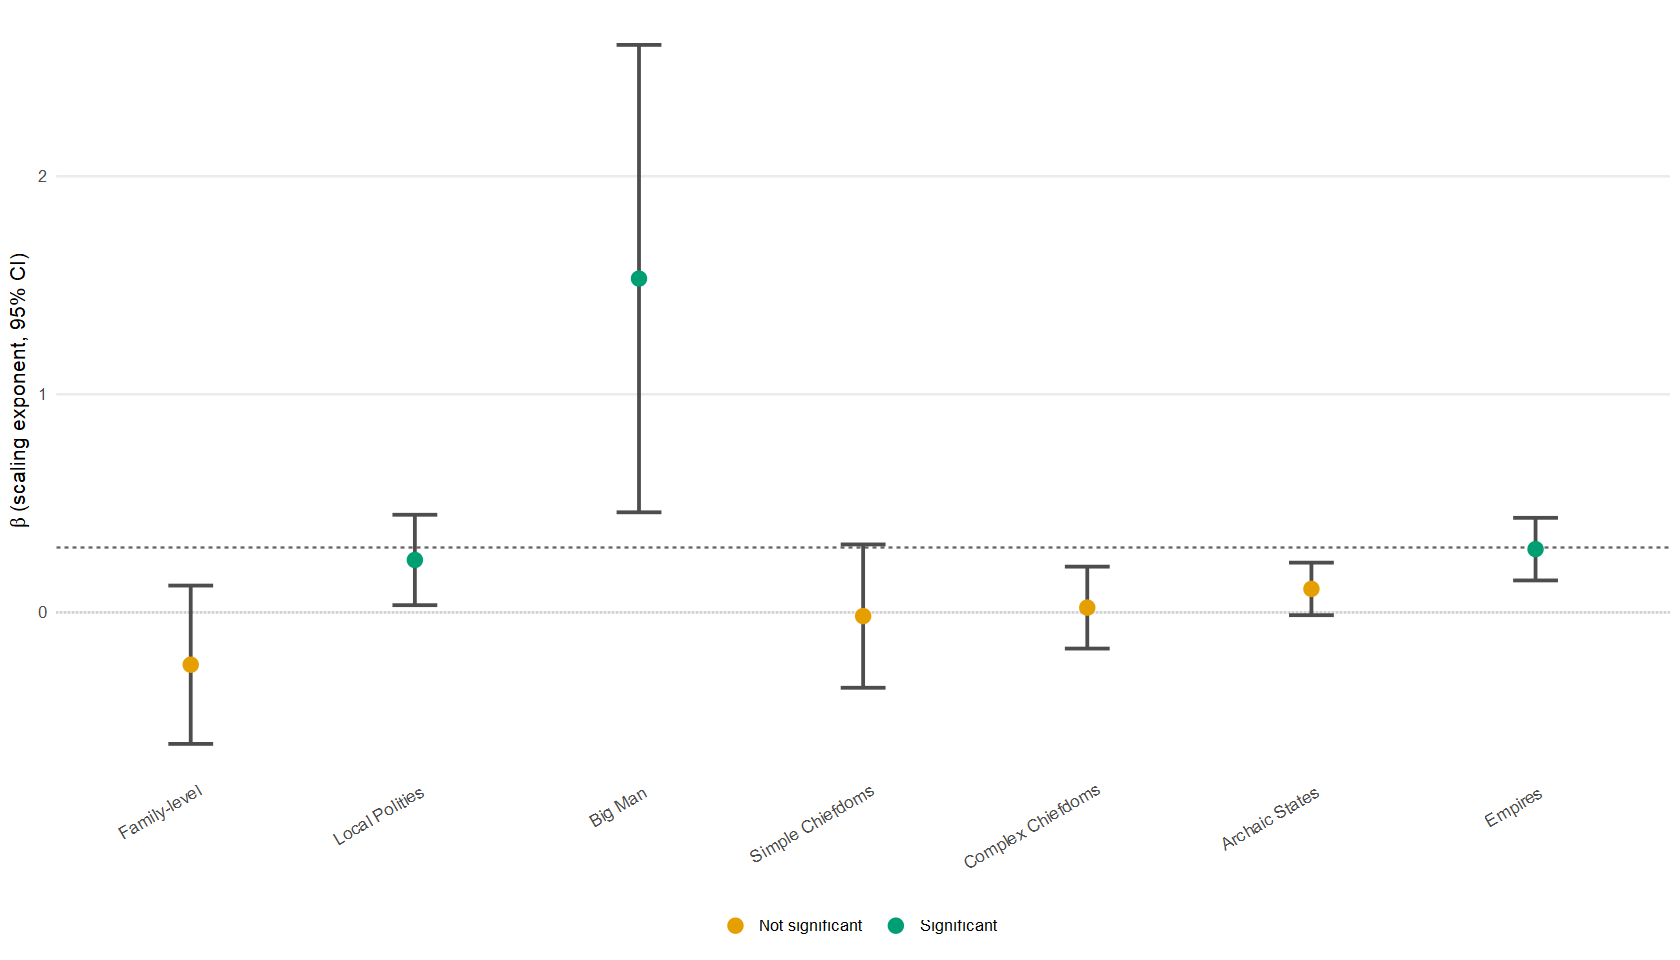

In [27]:
options(width = 200, repr.plot.width = 14, repr.plot.height = 8)

# classify each site into one of the seven polity types
data_clean <- data_clean %>%
  mutate(
    Polity_Type = case_when(
      TypeOfPolity == 1 ~ "Family-level",
      TypeOfPolity == 2 ~ "Local Polities",
      TypeOfPolity == 3 ~ "Big Man",
      TypeOfPolity == 4 ~ "Simple Chiefdoms",
      TypeOfPolity == 5 ~ "Complex Chiefdoms",
      TypeOfPolity == 6 ~ "Archaic States",
      TypeOfPolity == 7 ~ "Empires",
      TRUE ~ NA_character_
    ),
    Polity_Type = factor(Polity_Type, levels = c(
      "Family-level", "Local Polities", "Big Man",
      "Simple Chiefdoms", "Complex Chiefdoms", "Archaic States", "Empires"
    ))
  )

# fit the model within each polity type (types with at least 5 site-phases)
polity_type_results <- map_dfr(levels(data_clean$Polity_Type), function(pt) {
  sub <- data_clean %>% filter(Polity_Type == pt)
  if (n_distinct(sub$site_id) < 5) return(NULL)
  tryCatch(
    calc_mixed(sub, pt),
    error = function(e) NULL
  )
})

# Table S9
table_s9 <- map_dfr(group_order, function(grp) {
  calc_mixed(data_clean %>% filter(Polity_Group == grp), grp)
}) %>%
  transmute(
    Polity_Group   = Analysis,
    Beta           = round(Beta, 4),
    SE             = round(SE, 4),
    df_Satt        = round(df_satt, 1),
    P_value        = formatC(P_value, format = "e", digits = 2),
    R2_marginal    = round(R2_marginal, 4),
    R2_conditional = round(R2_conditional, 4),
    ICC            = round(ICC, 4),
    N_buildings    = N_buildings,
    N_sites        = N_sites,
    N_site_phases  = N_site_phases
  )

show_table(as.data.frame(table_s9), "S9 Table. Scaling relationship by polity group (three complexity groups)")

# Figure S3
fig_s3 <- ggplot(polity_type_results,
                 aes(x = factor(Analysis, levels = levels(data_clean$Polity_Type)),
                     y = Beta)) +
  geom_hline(yintercept = 0, linetype = "dotted", colour = "grey70") +
  geom_hline(yintercept = 0.298, linetype = "dashed", colour = "grey40", linewidth = 0.5) +
  geom_errorbar(aes(ymin = Beta - 1.96 * SE, ymax = Beta + 1.96 * SE),
                width = 0.2, linewidth = 0.8, colour = "grey30") +
  geom_point(aes(colour = ifelse(P_value < 0.05, "Significant", "Not significant")),
             size = 3.5) +
  scale_colour_manual(values = c("Significant" = okabe_ito[3],
                                 "Not significant" = okabe_ito[1])) +
  labs(
    y = expression(beta ~ "(scaling exponent, 95% CI)"),
    x = NULL, colour = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom", panel.grid.minor = element_blank(),
        panel.grid.major.x = element_blank(),
        axis.text.x = element_text(angle = 30, hjust = 1, size = 10))

fig_caption(paste0(
  "S3 Fig. Scaling exponent by polity type, with 95% CI. ",
  "Dotted line marks zero; dashed line marks the overall baseline exponent (0.298). ",
  "Green = significant, orange = not significant."
))
fig_s3

## Section S8 — Robustness of the inequality results to the choice of dispersion metric

Check that the inequality findings do not depend on using the Gini coefficient specifically. Recompute within-site dispersion with two alternative metrics: the variance of log house area, and the P90/P10 ratio (the ratio of the largest to the smallest houses). Correlate each with settlement size by polity group (S10 Table), and confirm that all three metrics agree with one another (their pairwise correlations are reported inline). Display both alternative metrics against settlement size, faceted by polity group (S4 Fig). The pattern is the same as for the Gini: a positive size–inequality relationship only in high-complexity polities. 

**Produces S10 Table and S4 Fig.**

Polity_group,N,r_logvar,p_logvar,r_9010,p_9010
Low (Family/Local),36,-0.091,5.98e-01,0.047,7.87e-01
Mid (Big Man/Chiefdoms),29,-0.131,4.98e-01,-0.117,5.44e-01
High (States/Empires),36,0.504,1.74e-03,0.271,1.10e-01


Convergence between the Gini coefficient and the two alternative dispersion metrics

Gini vs log-variance: r = 0.887 , p = 5.22e-35 
Gini vs log(P90/P10): r = 0.8 , p = 1.07e-23 


S4 Fig. Two alternative dispersion metrics (variance of log house area; log P90/P10 ratio) vs settlement size, faceted by polity group. Dashed line marks 10 ha.

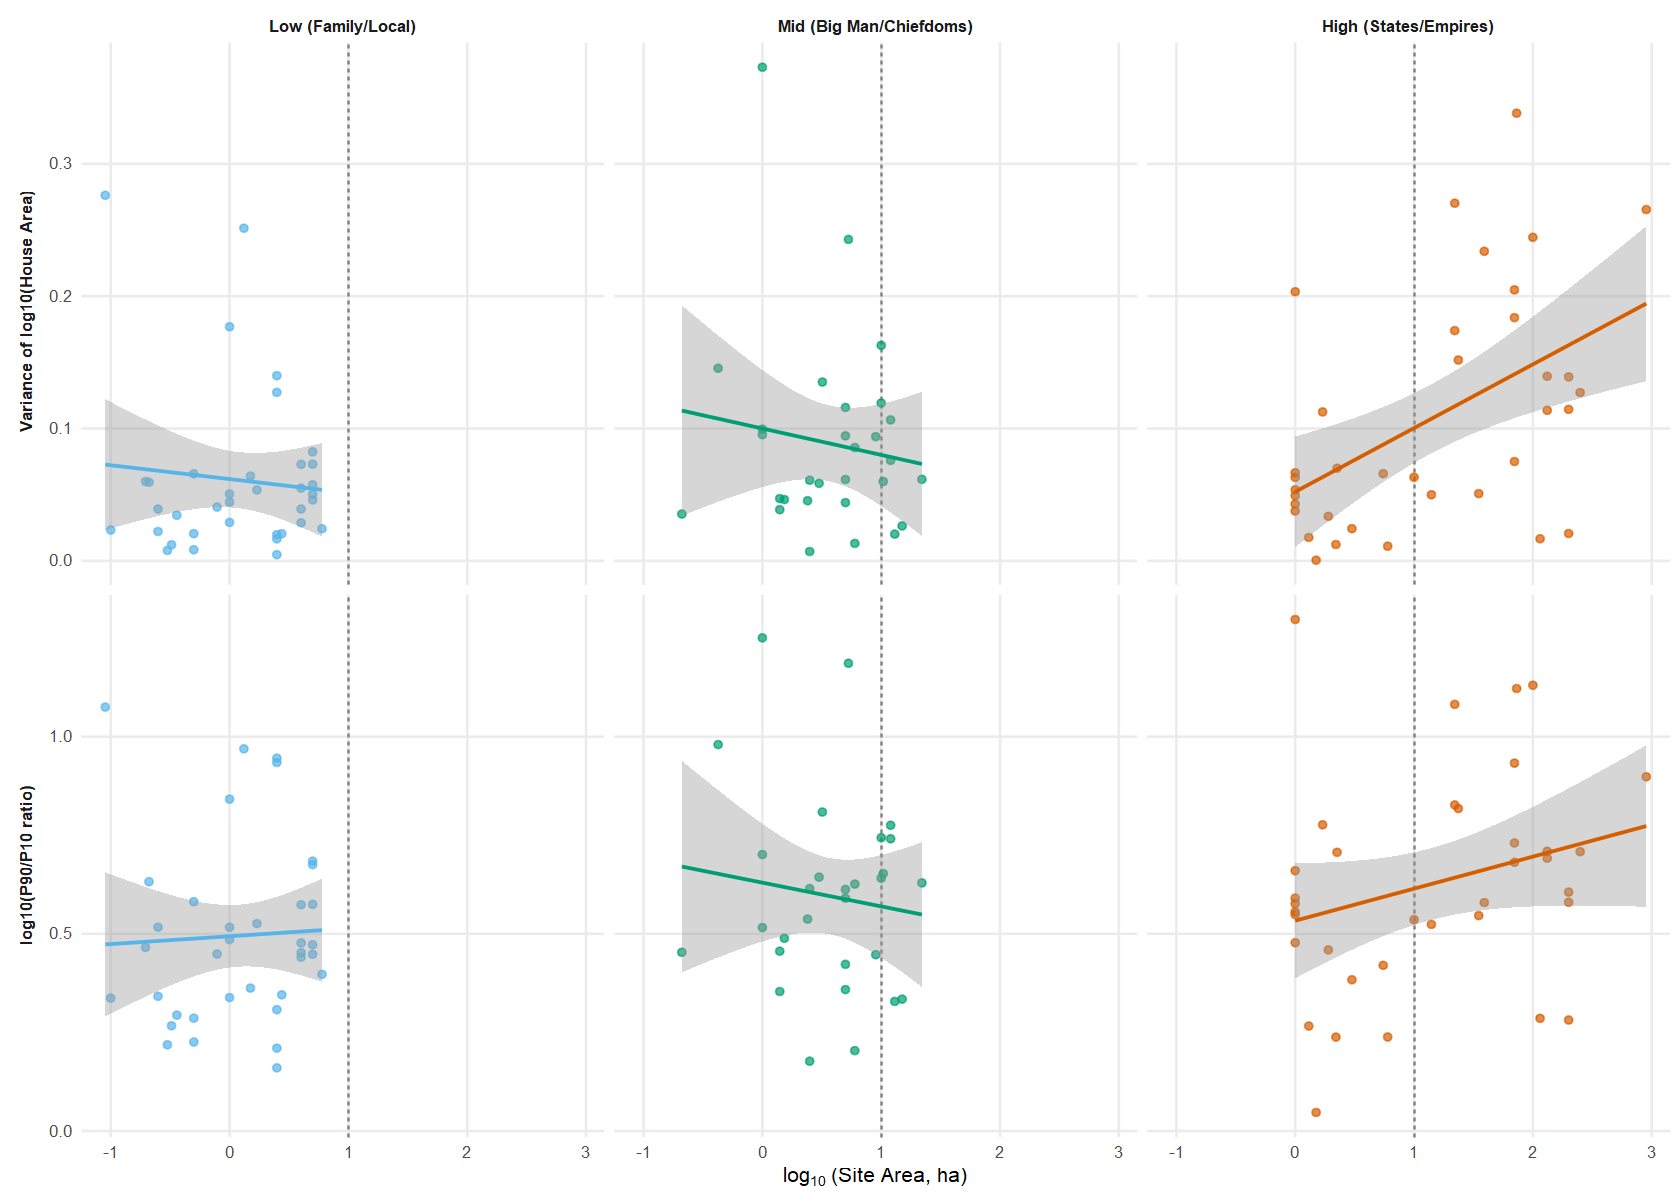

In [29]:
options(width = 200, repr.plot.width = 14, repr.plot.height = 10)

# compute two alternative dispersion metrics per site-phase (log-variance and P90/P10 ratio)
disp_data <- data_clean %>%
  group_by(site_id, Site, TotalArea, log_site_area,
           Polity_Group, SitePeriod) %>%
  summarise(
    N_houses  = n(),
    log_var   = var(log10(TotalAreaHouse)),
    p90       = quantile(TotalAreaHouse, 0.90, na.rm = TRUE, type = 7),
    p10       = quantile(TotalAreaHouse, 0.10, na.rm = TRUE, type = 7),
    .groups = "drop"
  ) %>%
  filter(N_houses >= 5) %>%
  mutate(ratio_9010 = p90 / p10) %>%
  left_join(
    data_clean %>%
      group_by(site_id) %>%
      summarise(
        Site_rank = ifelse(first(na.omit(WhichLevel / NOfLevels)) >= 0.7,
                           "Major centre", "Minor/peripheral"),
        .groups = "drop"
      ),
    by = "site_id"
  )

# Table S10
table_s10 <- map_dfr(group_order, function(grp) {
  sub <- disp_data %>% filter(Polity_Group == grp)
  if (nrow(sub) >= 5) {
    ct_var <- cor.test(sub$log_site_area, sub$log_var)
    ct_rat <- cor.test(sub$log_site_area, log10(sub$ratio_9010))
    tibble(
      Polity_group = grp,
      N = nrow(sub),
      r_logvar  = round(as.numeric(ct_var$estimate), 3),
      p_logvar  = formatC(ct_var$p.value, format = "e", digits = 2),
      r_9010    = round(as.numeric(ct_rat$estimate), 3),
      p_9010    = formatC(ct_rat$p.value, format = "e", digits = 2)
    )
  }
})
show_table(as.data.frame(table_s10), "S10 Table. Correlation of alternative dispersion metrics (log-variance, P90/P10) with settlement size, by polity group")

# check that the three dispersion metrics agree with one another
conv <- disp_data %>%
  left_join(gini_data %>% select(site_id, Gini), by = "site_id")
cv_gini_var  <- cor.test(conv$Gini, conv$log_var)
cv_gini_9010 <- cor.test(conv$Gini, log10(conv$ratio_9010))

fig_caption("Convergence between the Gini coefficient and the two alternative dispersion metrics")
cat("Gini vs log-variance: r =", round(cv_gini_var$estimate, 3),
    ", p =", formatC(cv_gini_var$p.value, format = "e", digits = 2), "\n")
cat("Gini vs log(P90/P10): r =", round(cv_gini_9010$estimate, 3),
    ", p =", formatC(cv_gini_9010$p.value, format = "e", digits = 2), "\n")

# Figure S4
disp_long <- disp_data %>%
  filter(!is.na(Polity_Group)) %>%
  transmute(
    log_site_area, Polity_Group,
    `Variance of log10(House Area)` = log_var,
    `log10(P90/P10 ratio)`          = log10(ratio_9010)
  ) %>%
  pivot_longer(cols = c(`Variance of log10(House Area)`, `log10(P90/P10 ratio)`),
               names_to = "Metric", values_to = "value") %>%
  mutate(Metric = factor(Metric, levels = c("Variance of log10(House Area)",
                                            "log10(P90/P10 ratio)")))

fig_s4 <- ggplot(disp_long,
                 aes(x = log_site_area, y = value, colour = Polity_Group)) +
  geom_vline(xintercept = log10(10), linetype = "dashed",
             colour = "grey50", linewidth = 0.5) +
  geom_point(alpha = 0.7, size = 1.6) +
  geom_smooth(method = "lm", formula = y ~ x, se = TRUE, linewidth = 0.8) +
  scale_colour_manual(values = polity_cols) +
  facet_grid(Metric ~ factor(Polity_Group, levels = group_order),
             scales = "free_y", switch = "y") +
  labs(
    x = expression(log[10] ~ "(Site Area, ha)"),
    y = NULL,
    colour = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        panel.grid.minor = element_blank(),
        strip.text = element_text(face = "bold", size = 10),
        strip.placement = "outside")

fig_caption(paste0(
  "S4 Fig. Two alternative dispersion metrics (variance of log house area; log P90/P10 ratio) ",
  "vs settlement size, faceted by polity group. Dashed line marks 10 ha."
))
fig_s4

## Section S9 — Population density scaling and sensitivity of the residential correction

Report the per-period density scaling (households per hectare against settlement size), both uncorrected and after the residential-proportion correction (S11 Table). Then test how sensitive the corrected exponent is to the correction itself: sweep the two endpoints of the correction (the residential proportion assumed at small and large sites) over a grid, refit the corrected scaling for each combination, and summarise the resulting range of exponents per period against the values expected under settlement scaling theory (S12 Table). A heat-map shows the corrected exponent across the whole grid (S5 Fig). 

**Produces S11 Table, S12 Table and S5 Fig.**

Period,N_site_phases,Beta_uncorr,SE_uncorr,P_uncorr,HH_per_ha_uncorr,Beta_corr,SE_corr,P_corr,HH_per_ha_corr
Neolithic,24,0.517,0.171,6.28e-03,64.4,0.517,0.171,6.28e-03,64.4
Chalcolithic,18,0.950,0.197,1.88e-04,71.9,0.880,0.196,3.67e-04,63.4
Bronze Age,38,0.866,0.114,5.07e-09,40.3,0.789,0.113,3.29e-08,35.7
Iron Age,16,0.775,0.198,1.57e-03,46.4,0.694,0.198,3.47e-03,41.8


SitePeriod,Beta_min,Beta_max,Beta_baseline,SST_prediction
Chalcolithic,0.834,0.950,0.880,0.833
Bronze Age,0.733,0.866,0.789,0.833
Iron Age,0.646,0.775,0.694,0.667


S5 Fig. Corrected density exponent across the grid of residential-proportion endpoints, per period. The cross marks the baseline correction (0.90 at 1 ha, 0.60 at 100 ha).

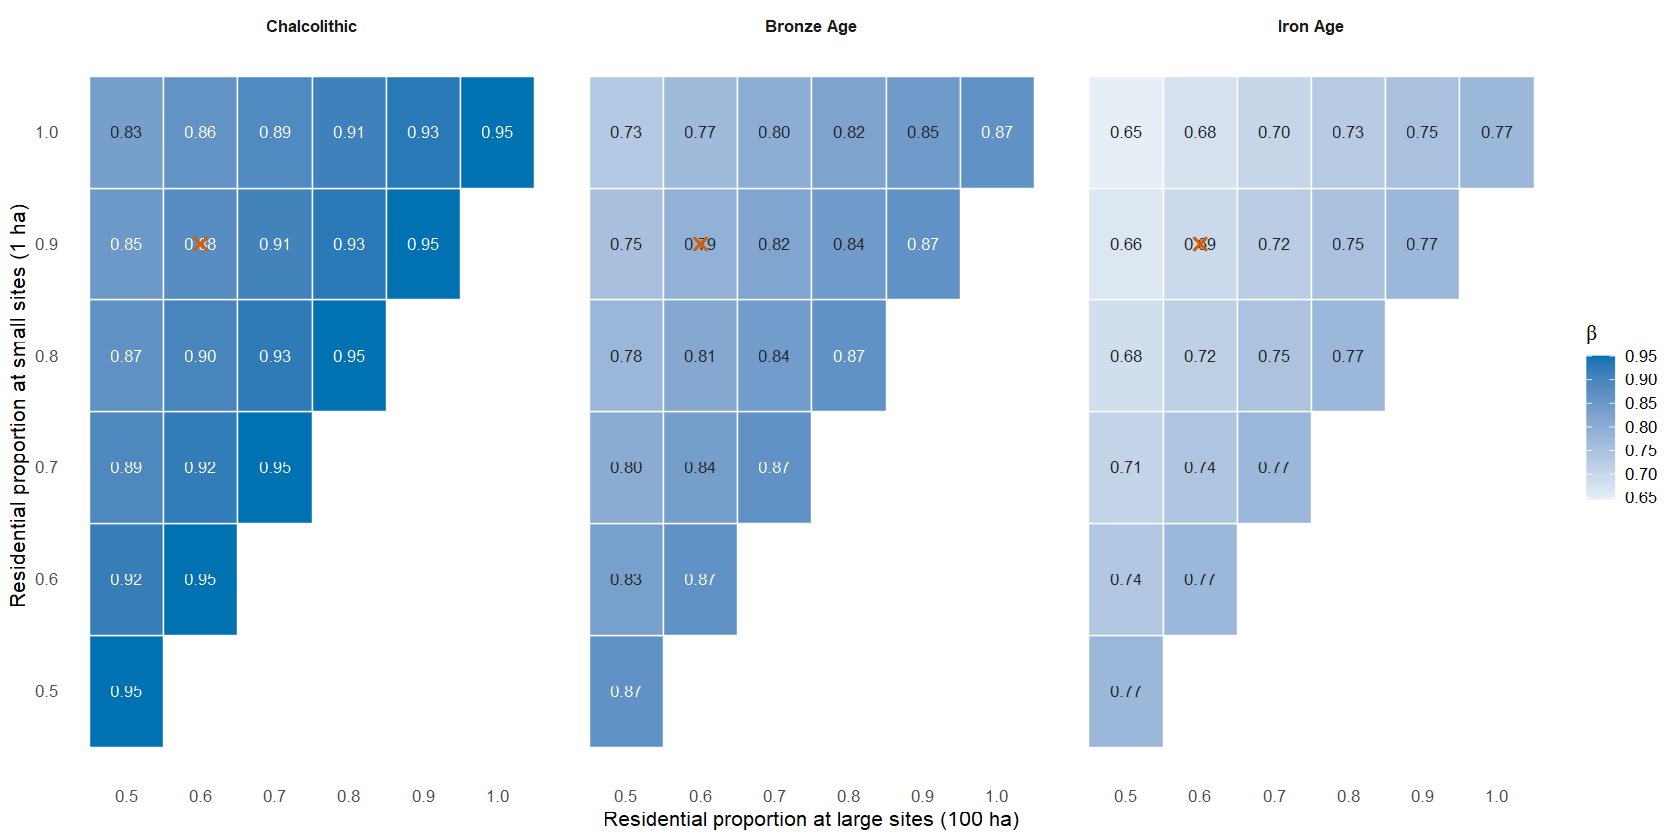

In [30]:
options(width = 200, repr.plot.width = 14, repr.plot.height = 7)

# clean and aggregate to site-phase level
KERKENES_ID <- 119113
ZINCIRLI_ID <- 119136

pop_data <- data_clean %>%
  filter(SitePeriod != "Paleolithic",
         !site_id %in% c(KERKENES_ID, ZINCIRLI_ID),
         !is.na(WindowArea), WindowArea > 0) %>%
  group_by(site_id, Site, SitePeriod, TotalArea, WindowArea) %>%
  summarise(
    WindowHH = n(),
    mean_HA  = mean(TotalAreaHouse, na.rm = TRUE),
    .groups  = "drop"
  ) %>%
  mutate(
    TotalHH       = (WindowHH / WindowArea) * TotalArea,
    log_TotalArea = log10(TotalArea),
    log_TotalHH   = log10(TotalHH),
    SitePeriod    = factor(SitePeriod, levels = c("Neolithic", "Chalcolithic",
                                                  "Bronze Age", "Iron Age"))
  )

# residential correction as a function of the two endpoints (small and large sites)
res_prop_fun <- function(area, hi, lo) {
  pmax(lo, pmin(hi, hi - (hi - lo) * log10(area) / log10(100)))
}

pop_data <- pop_data %>%
  mutate(
    res_prop = if_else(SitePeriod == "Neolithic", 1.0,
                       res_prop_fun(TotalArea, hi = 0.90, lo = 0.60)),
    TotalHH_res     = TotalHH * res_prop,
    log_TotalHH_res = log10(TotalHH_res)
  )

# Table S11
table_s11 <- pop_data %>%
  group_by(SitePeriod) %>%
  group_map(~ {
    m_unc <- lm(log_TotalHH     ~ log_TotalArea, data = .x)
    m_res <- lm(log_TotalHH_res ~ log_TotalArea, data = .x)
    s_unc <- summary(m_unc); s_res <- summary(m_res)
    tibble(
      Period           = .y$SitePeriod,
      N_site_phases    = nrow(.x),
      Beta_uncorr      = round(coef(m_unc)[2], 3),
      SE_uncorr        = round(s_unc$coefficients[2, 2], 3),
      P_uncorr         = formatC(s_unc$coefficients[2, 4], format = "e", digits = 2),
      HH_per_ha_uncorr = round(10^coef(m_unc)[1], 1),
      Beta_corr        = round(coef(m_res)[2], 3),
      SE_corr          = round(s_res$coefficients[2, 2], 3),
      P_corr           = formatC(s_res$coefficients[2, 4], format = "e", digits = 2),
      HH_per_ha_corr   = round(10^coef(m_res)[1], 1)
    )
  }) %>% bind_rows()
show_table(as.data.frame(table_s11), "S11 Table. Per-period density scaling: uncorrected vs residential-corrected")

# sweep the two correction endpoints over a grid and refit the corrected exponent
grid <- expand_grid(hi = seq(0.50, 1.00, 0.10),
                    lo = seq(0.50, 1.00, 0.10)) %>%
  filter(hi >= lo)

sens_res <- pmap_dfr(grid, function(hi, lo) {
  pop_data %>%
    filter(SitePeriod != "Neolithic") %>%
    mutate(y = log10(TotalHH * res_prop_fun(TotalArea, hi, lo))) %>%
    group_by(SitePeriod) %>%
    summarise(Beta = coef(lm(y ~ log_TotalArea))[2], .groups = "drop") %>%
    mutate(hi = hi, lo = lo)
}) %>%
  mutate(SitePeriod = factor(SitePeriod,
                             levels = c("Chalcolithic", "Bronze Age", "Iron Age")))

sst_pred <- tibble(SitePeriod = c("Chalcolithic", "Bronze Age", "Iron Age"),
                   SST_prediction = round(c(5/6, 5/6, 2/3), 3))

# Table S12
table_s12 <- sens_res %>%
  group_by(SitePeriod) %>%
  summarise(
    Beta_min      = round(min(Beta), 3),
    Beta_max      = round(max(Beta), 3),
    Beta_baseline = round(Beta[hi == 0.90 & lo == 0.60], 3),
    .groups = "drop"
  ) %>%
  left_join(sst_pred, by = "SitePeriod")
show_table(as.data.frame(table_s12), "S12 Table. Sensitivity of the corrected density exponent across the correction grid, vs settlement scaling theory predictions")

# Figure S5
fig_s5 <- ggplot(sens_res, aes(x = lo, y = hi, fill = Beta)) +
  geom_tile(colour = "white", linewidth = 0.3) +
  geom_text(aes(label = sprintf("%.2f", Beta),
                colour = Beta > 0.85), size = 3.5) +
  geom_point(data = tibble(lo = 0.60, hi = 0.90),
             aes(x = lo, y = hi), shape = 4, size = 2.6, stroke = 1,
             colour = "#D55E00", inherit.aes = FALSE) +
  scale_fill_gradient(low = "#E6EEF6", high = "#0072B2", name = expression(beta)) +
  scale_colour_manual(values = c("FALSE" = "grey15", "TRUE" = "white"),
                      guide = "none") +
  facet_wrap(~ SitePeriod, ncol = 3) +
  scale_x_continuous(breaks = seq(0.5, 1, 0.1)) +
  scale_y_continuous(breaks = seq(0.5, 1, 0.1)) +
  labs(
    x = "Residential proportion at large sites (100 ha)",
    y = "Residential proportion at small sites (1 ha)"
  ) +
  theme_minimal(base_size = 12) +
  theme(panel.grid = element_blank(),
        strip.text = element_text(face = "bold", size = 10))

fig_caption(paste0(
  "S5 Fig. Corrected density exponent across the grid of residential-proportion endpoints, per period. ",
  "The cross marks the baseline correction (0.90 at 1 ha, 0.60 at 100 ha)."
))
fig_s5

## Section S10 — Tests on the Neolithic absence of scaling

Examine three alternative explanations for the absence of a scaling relationship in the Neolithic: that it reflects the pooling of geographically distinct regions (Test 1, geographic centring), that it is masked by mixing two storage regimes (Test 2), or that it is hidden by the under-recording of upper-storey space at larger houses (Test 3). 

**Produces S6 Fig, S13 Table and S14 Table.**

Test 1 - Geographic centring. Centre the area-household relationship at finer geographic levels (by subregion, by subarea, by subarea x period) and refit per period; a hidden positive slope would appear if the flat Neolithic result were only an artefact of pooling regions with different baselines.

S6 Fig. Density scaling exponent per period under successive geographic centring (uncentered, by subregion, by subarea, by subarea x period). Dashed line marks the theoretical 2/3; filled points significant, open points not significant.

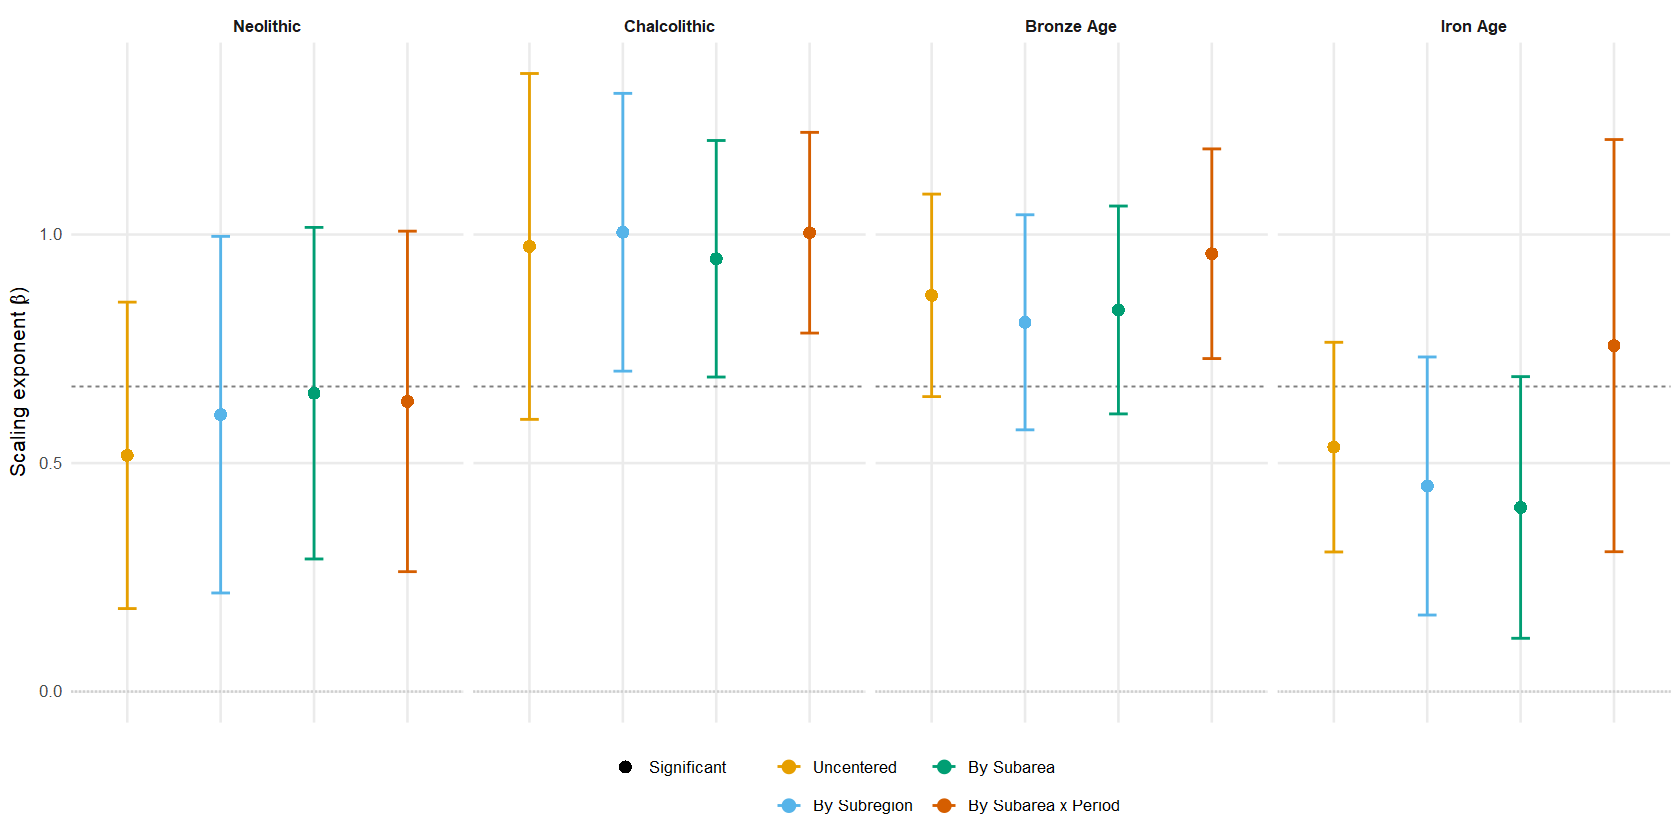

In [31]:
options(width = 200, repr.plot.width = 14, repr.plot.height = 7)

fig_caption("Test 1 - Geographic centring. Centre the area-household relationship at finer geographic levels (by subregion, by subarea, by subarea x period) and refit per period; a hidden positive slope would appear if the flat Neolithic result were only an artefact of pooling regions with different baselines.")

# aggregate to site-phase level with the geographic labels needed for centring
site_agg_neo <- data_clean %>%
  filter(SitePeriod != "Paleolithic") %>%
  group_by(site_id, Site, SitePeriod, TotalArea, WindowArea, WindowHH,
           Subarea, Subregion) %>%
  summarise(mean_HA = mean(TotalAreaHouse, na.rm = TRUE), n_houses = n(),
            .groups = "drop") %>%
  filter(!is.na(WindowHH), !is.na(WindowArea), WindowArea > 0, WindowHH > 0) %>%
  mutate(
    TotalHH       = (WindowHH / WindowArea) * TotalArea,
    log_TotalHH   = log10(TotalHH),
    log_TotalArea = log10(TotalArea),
    SitePeriod    = factor(SitePeriod, levels = c("Neolithic", "Chalcolithic",
                                                  "Bronze Age", "Iron Age")),
    SubareaXPeriod = paste(Subarea, SitePeriod, sep = " x ")
  )

# centre area and households within a grouping level, then refit per period
center_and_fit_agg <- function(data, group_var, label) {
  data %>%
    group_by(across(all_of(group_var))) %>%
    mutate(x_c = log_TotalArea - mean(log_TotalArea, na.rm = TRUE),
           y_c = log_TotalHH   - mean(log_TotalHH,   na.rm = TRUE)) %>%
    ungroup() %>%
    group_by(SitePeriod) %>%
    group_map(~ {
      if (nrow(.x) < 4) return(NULL)
      m <- lm(y_c ~ x_c, data = .x); s <- summary(m)
      tibble(Period = .y$SitePeriod, Beta = round(coef(m)[2], 3),
             SE = round(s$coefficients[2, 2], 3), P = s$coefficients[2, 4],
             N = nrow(.x), Centering = label)
    }) %>% bind_rows()
}

# uncentred fit for reference
centering_uncentered <- site_agg_neo %>%
  group_by(SitePeriod) %>%
  group_map(~ {
    m <- lm(log_TotalHH ~ log_TotalArea, data = .x); s <- summary(m)
    tibble(Period = .y$SitePeriod, Beta = round(coef(m)[2], 3),
           SE = round(s$coefficients[2, 2], 3), P = s$coefficients[2, 4],
           N = nrow(.x), Centering = "Uncentered")
  }) %>% bind_rows()

# combine the uncentred fit with the three centring levels
centering_results <- bind_rows(
  centering_uncentered,
  center_and_fit_agg(site_agg_neo, "Subarea", "By Subarea"),
  center_and_fit_agg(site_agg_neo, "Subregion", "By Subregion"),
  center_and_fit_agg(site_agg_neo, "SubareaXPeriod", "By Subarea x Period")
) %>%
  mutate(
    CI_low  = Beta - 1.96 * SE, CI_high = Beta + 1.96 * SE,
    Sig = ifelse(P < 0.05, "Significant", "Not significant"),
    Centering = factor(Centering, levels = c("Uncentered", "By Subregion",
                                             "By Subarea", "By Subarea x Period"))
  )

centering_cols <- setNames(okabe_ito[c(1, 2, 3, 6)],
                           c("Uncentered", "By Subregion",
                             "By Subarea", "By Subarea x Period"))

# Figure S6
fig_s6 <- ggplot(centering_results,
                 aes(x = Centering, y = Beta, colour = Centering, shape = Sig)) +
  geom_hline(yintercept = 0, linetype = "dotted", colour = "grey70") +
  geom_hline(yintercept = 2/3, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  geom_errorbar(aes(ymin = CI_low, ymax = CI_high), width = 0.2, linewidth = 0.6) +
  geom_point(size = 3) +
  scale_colour_manual(values = centering_cols) +
  scale_shape_manual(values = c("Significant" = 16, "Not significant" = 1)) +
  facet_wrap(~ Period, ncol = 4) +
  labs(x = NULL, y = expression("Scaling exponent (" * beta * ")"),
       colour = NULL, shape = NULL) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom", panel.grid.minor = element_blank(),
        axis.text.x = element_blank(), axis.ticks.x = element_blank(),
        strip.text = element_text(face = "bold")) +
  guides(colour = guide_legend(nrow = 2))

fig_caption(paste0(
  "S6 Fig. Density scaling exponent per period under successive geographic centring ",
  "(uncentered, by subregion, by subarea, by subarea x period). Dashed line marks the theoretical 2/3; ",
  "filled points significant, open points not significant."
))
fig_s6

In [32]:
options(width = 200)

fig_caption("Test 2 - Storage regime. Split the Neolithic sites into communal vs privatised storage and refit the scaling model within each group.")

# archaeological classification of each Neolithic site as communal or privatised storage
storage_class <- tribble(
  ~site_id, ~storage,
  141136,"Communal",119110,"Communal",141169,"Communal",119138,"Communal",
  119146,"Communal",141143,"Communal",119117,"Communal",119145,"Communal",
  119102,"Communal",119114,"Communal",141120,"Communal",141116,"Communal",
  119144,"Privatised",119109,"Privatised",119147,"Privatised",119106,"Privatised",
  119105,"Privatised",141162,"Privatised",119107,"Privatised",119126,"Privatised",
  141137,"Privatised",119155,"Privatised"
)

data_neo_storage <- data_clean %>%
  filter(SitePeriod == "Neolithic") %>%
  left_join(storage_class, by = "site_id") %>%
  mutate(storage = factor(storage, levels = c("Communal", "Privatised")))

# fit the scaling model within a storage group
fit_storage <- function(group_data, group_label) {
  m <- lmer(log_house_area ~ log_site_area + (1 | site_id), data = group_data)
  s <- coef(summary(m))
  tibble(
    Storage_regime = group_label,
    N_sites     = n_distinct(group_data$site_id),
    N_buildings = nrow(group_data),
    Beta        = round(s["log_site_area", "Estimate"], 3),
    SE          = round(s["log_site_area", "Std. Error"], 3),
    P           = formatC(s["log_site_area", "Pr(>|t|)"], format = "f", digits = 4),
    Intercept   = round(s["(Intercept)", "Estimate"], 4),
    Y0_m2       = round(10^s["(Intercept)", "Estimate"], 1)
  )
}

# Table S13
table_s13 <- bind_rows(
  fit_storage(data_neo_storage %>% filter(storage == "Communal"),   "Communal"),
  fit_storage(data_neo_storage %>% filter(storage == "Privatised"), "Privatised")
)
show_table(as.data.frame(table_s13), "S13 Table. Neolithic scaling by storage regime (communal vs privatised)")

Test 2 - Storage regime. Split the Neolithic sites into communal vs privatised storage and refit the scaling model within each group.

Storage_regime,N_sites,N_buildings,Beta,SE,P,Intercept,Y0_m2
Communal,12,191,0.091,0.145,0.5421,1.0799,12.0
Privatised,10,124,-0.012,0.252,0.9619,1.4887,30.8


In [33]:
options(width = 200)

fig_caption("Test 3 - Simulation of unrecorded vertical space. Double house areas above a series of settlement-size thresholds among privatised sites and refit at each threshold.")

priv_data <- data_neo_storage %>% filter(storage == "Privatised")

# baseline fit with no correction, for reference
m_priv_orig <- lmer(log_house_area ~ log_site_area + (1 | site_id), data = priv_data)
s_priv_orig <- coef(summary(m_priv_orig))
results_baseline <- tibble(
  Threshold_ha = "None (baseline)", Sites_doubled = 0,
  Sites_total  = n_distinct(priv_data$site_id),
  Beta = round(s_priv_orig["log_site_area", "Estimate"], 3),
  SE   = round(s_priv_orig["log_site_area", "Std. Error"], 3),
  P    = formatC(s_priv_orig["log_site_area", "Pr(>|t|)"], format = "f", digits = 4),
  Y0_m2 = round(10^s_priv_orig["(Intercept)", "Estimate"], 1)
)

# refit after doubling house areas above each size threshold
thresholds <- c(0.5, 1.0, 1.5, 2.0, 2.5)
results_thresh <- map_dfr(thresholds, function(th) {
  priv_test <- priv_data %>%
    mutate(log_house_corr = log10(ifelse(TotalArea >= th,
                                         TotalAreaHouse * 2, TotalAreaHouse)))
  m <- lmer(log_house_corr ~ log_site_area + (1 | site_id), data = priv_test)
  s <- coef(summary(m))
  tibble(
    Threshold_ha  = as.character(th),
    Sites_doubled = n_distinct(priv_test$site_id[priv_test$TotalArea >= th]),
    Sites_total   = n_distinct(priv_test$site_id),
    Beta = round(s["log_site_area", "Estimate"], 3),
    SE   = round(s["log_site_area", "Std. Error"], 3),
    P    = formatC(s["log_site_area", "Pr(>|t|)"], format = "f", digits = 4),
    Y0_m2 = round(10^s["(Intercept)", "Estimate"], 1)
  )
})

# Table S14
table_s14 <- bind_rows(results_baseline, results_thresh)
show_table(as.data.frame(table_s14), "S14 Table. Simulation of unrecorded vertical space among privatised Neolithic sites (house areas doubled above each size threshold)")

Test 3 - Simulation of unrecorded vertical space. Double house areas above a series of settlement-size thresholds among privatised sites and refit at each threshold.

Threshold_ha,Sites_doubled,Sites_total,Beta,SE,P,Y0_m2
None (baseline),0,10,-0.012,0.252,0.9619,30.8
0.5,8,10,0.263,0.233,0.2945,50.8
1,7,10,0.302,0.275,0.3048,47.2
1.5,5,10,0.335,0.277,0.2614,41.0
2,5,10,0.335,0.277,0.2614,41.0
2.5,5,10,0.335,0.277,0.2614,41.0


## Section S11 — Hierarchy Position threshold sensitivity

Test whether the inequality result for high-complexity polities depends on the specific cut-off used to define "major centres" (HP ≥ 0.7 in the main analysis). Within high-complexity polities, re-split the sites into major vs minor at four alternative thresholds (0.5, 0.6, 0.7, 0.8) and recompute, for each, the correlation between settlement size and inequality in both groups. If the positive size–inequality relationship at major centres holds across thresholds, it is not an artefact of the chosen cut-off. 

**Produces S15 Table.**

In [34]:
options(width = 200)

# high-complexity polities only
high_data <- gini_data %>% filter(Polity_Group == "High (States/Empires)")

# Table S15
table_s15 <- map_dfr(c(0.5, 0.6, 0.7, 0.8), function(th) {
  major <- high_data %>% filter(HP >= th)
  minor <- high_data %>% filter(HP < th)

  r_maj <- if (nrow(major) >= 5) {
    ct <- cor.test(major$log_site_area, major$Gini)
    list(r = round(as.numeric(ct$estimate), 3), p = ct$p.value)
  } else list(r = NA_real_, p = NA_real_)

  r_min <- if (nrow(minor) >= 5) {
    ct <- cor.test(minor$log_site_area, minor$Gini)
    list(r = round(as.numeric(ct$estimate), 3), p = ct$p.value)
  } else list(r = NA_real_, p = NA_real_)

  tibble(
    Threshold   = th,
    N_major     = nrow(major),
    N_minor     = nrow(minor),
    Gini_major  = round(mean(major$Gini), 3),
    Gini_minor  = if (nrow(minor) > 0) round(mean(minor$Gini), 3) else NA_real_,
    r_major     = r_maj$r,
    p_major     = formatC(r_maj$p, format = "e", digits = 2),
    r_minor     = r_min$r,
    p_minor     = formatC(r_min$p, format = "e", digits = 2)
  )
})

show_table(as.data.frame(table_s15), "S15 Table. Sensitivity of the size-inequality relationship in high-complexity polities to the Hierarchy Position threshold")

Threshold,N_major,N_minor,Gini_major,Gini_minor,r_major,p_major,r_minor,p_minor
0.5,31,5,0.438,0.405,0.628,1.54e-04,-0.156,8.02e-01
0.6,29,7,0.444,0.389,0.626,2.79e-04,-0.330,4.69e-01
0.7,21,15,0.526,0.303,0.439,4.67e-02,-0.087,7.58e-01
0.8,18,18,0.521,0.345,0.272,2.75e-01,0.685,1.70e-03


---

### End of notebook

This notebook reproduced all tables and figures of the main text (Sections 1–7) and the Supplementary Material (Sections S1–S11). All results were generated from `dataset.csv` using the packages and functions defined in the Setup section.

To re-run the full analysis from scratch, restart the kernel and select **Run All**; the notebook executes top to bottom without manual intervention.

Data, scripts and this notebook are archived at [10.5281/zenodo.20172244](https://doi.org/10.5281/zenodo.20172244).